In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.preprocessing import MaxAbsScaler
from sklearn.svm import SVR
from tensorflow.keras.layers import GRU, LSTM, Dense, Dropout
from itertools import combinations
from sklearn.metrics import r2_score

In [2]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Tdata.csv')

In [3]:
data

,Date,Avg_Usr,Avg_Usr_TP_DL,Avg_Usr_TP_UL,CSSR,DL_256QAM_PROPORTION,DL_LATENCY,DL_PACK_LOSS_RATE,DL_QPSK_PROPORTION,DL_TRAFFIC_MB,Max_Usr,S1_SIG_SUCC,TOTAL_DOWNTIME,Traffic,UL_QPSK_PROPORTION,UL_TRAFFIC_MB
0,1-Sep-22,16209.61,3.446027,0.564643,98.698393,0.745357,11.741116,0.101875,36.163527,28748026.10,32848,251968.1429,393.651786,32890183.17,37.050402,4142157.11
1,2-Sep-22,16003.68,3.250536,0.582187,98.690223,0.700536,11.614241,0.115580,35.475402,29619777.66,32313,243918.5625,389.156250,34033315.47,38.724911,4413537.60
2,3-Sep-22,16058.39,3.597009,0.609911,98.715045,0.739732,11.503259,0.096250,35.623393,29102851.45,32565,246798.6027,388.062500,33383868.74,36.708884,4281017.27
3,4-Sep-22,16390.15,3.726696,0.561250,98.599777,0.746696,11.807366,0.110536,35.997411,28466880.25,33303,257327.6563,387.245536,32606986.82,36.628527,4140106.66
4,5-Sep-22,16051.58,3.726473,0.537813,98.653527,0.751071,11.534911,0.111250,35.609866,28558733.04,32314,256012.4866,390.343750,32652591.96,37.344955,4093859.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,28-Aug-23,23298.68,7.064972,0.477116,99.415142,0.773226,7.505920,0.078786,38.537059,56768939.70,58629,127670.3321,1092.662239,63974723.71,42.272201,7205784.11
362,29-Aug-23,24511.92,6.966452,0.490361,99.463776,0.727324,7.704269,0.097002,38.737799,57456743.34,54688,129612.0247,1074.193548,64944563.74,40.884345,7487820.29
363,30-Aug-23,24467.48,6.898596,0.493188,99.626964,0.754516,7.891157,0.096129,38.392467,58389814.53,56111,133872.1556,362.741936,65854384.38,40.078159,7464569.80
364,31-Aug-23,23803.97,7.090190,0.510664,99.661120,0.809222,7.563378,0.088520,38.284099,59759544.72,51682,134106.0171,0.000000,67421649.20,39.138444,7662104.58


In [4]:
data.columns

Index(['Date', 'Avg_Usr', 'Avg_Usr_TP_DL', 'Avg_Usr_TP_UL', 'CSSR',
       'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE',
       'DL_QPSK_PROPORTION', 'DL_TRAFFIC_MB', 'Max_Usr', 'S1_SIG_SUCC',
       'TOTAL_DOWNTIME', 'Traffic', 'UL_QPSK_PROPORTION', 'UL_TRAFFIC_MB'],
      dtype='object')

Epoch 1/50
10/10 [==============================] - 9s 187ms/step - loss: 0.0571 - val_loss: 0.0208
Epoch 2/50
10/10 [==============================] - 0s 13ms/step - loss: 0.0168 - val_loss: 0.0416
Epoch 3/50
10/10 [==============================] - 0s 13ms/step - loss: 0.0078 - val_loss: 0.0678
Epoch 4/50
10/10 [==============================] - 0s 14ms/step - loss: 0.0061 - val_loss: 0.0130
Epoch 5/50
10/10 [==============================] - 0s 14ms/step - loss: 0.0051 - val_loss: 0.0220
Epoch 6/50
10/10 [==============================] - 0s 14ms/step - loss: 0.0043 - val_loss: 0.0086
Epoch 7/50
10/10 [==============================] - 0s 13ms/step - loss: 0.0038 - val_loss: 0.0054
Epoch 8/50
10/10 [==============================] - 0s 13ms/step - loss: 0.0035 - val_loss: 0.0047
Epoch 9/50
10/10 [==============================] - 0s 43ms/step - loss: 0.0033 - val_loss: 0.0043
Epoch 10/50
10/10 [==============================] - 0s 18ms/step - loss: 0.0033 - val_loss: 0.0043
Epoch 11

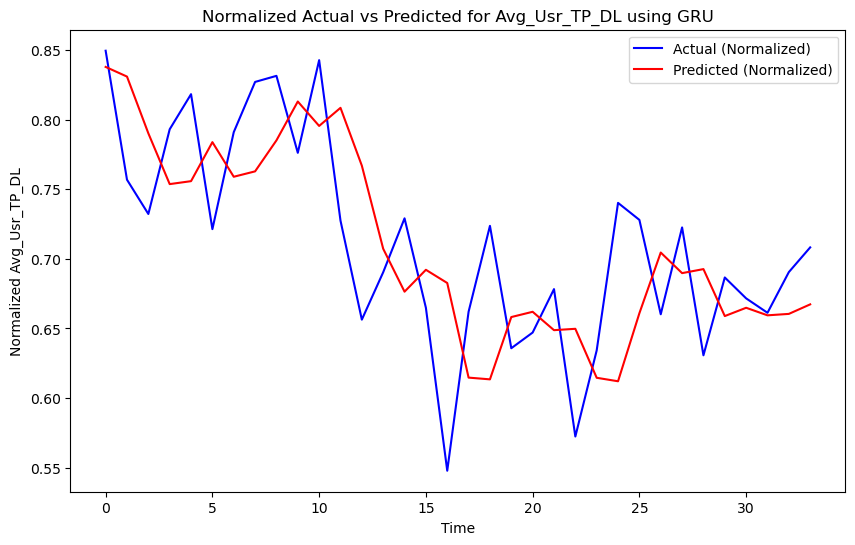

In [15]:
# Function to create dataset matrix for GRU
def create_dataset_gru(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'Avg_Usr_TP_DL'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.9)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for GRU (look_back=3)
look_back = 3
X_train, y_train = create_dataset_gru(train, look_back=look_back)
X_test, y_test = create_dataset_gru(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for GRU
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 1))
gru_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train)
test_predict_gru = gru_model.predict(X_test)

# Calculate MSE for the GRU model
gru_mse = mean_squared_error(y_test, test_predict_gru)
print(f'GRU Model MSE (Normalized): {gru_mse}')

# Calculate R-squared value
from sklearn.metrics import r2_score
gru_r2 = r2_score(y_test, test_predict_gru)
print(f'GRU Model R-squared (Normalized): {gru_r2}')

# Plot the GRU model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using GRU')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

Epoch 1/50
5/5 [==============================] - 8s 414ms/step - loss: 0.0541 - val_loss: 0.0412
Epoch 2/50
5/5 [==============================] - 0s 20ms/step - loss: 0.0115 - val_loss: 0.0011
Epoch 3/50
5/5 [==============================] - 0s 15ms/step - loss: 0.0124 - val_loss: 0.0016
Epoch 4/50
5/5 [==============================] - 0s 27ms/step - loss: 0.0061 - val_loss: 0.0105
Epoch 5/50
5/5 [==============================] - 0s 22ms/step - loss: 0.0061 - val_loss: 0.0152
Epoch 6/50
5/5 [==============================] - 0s 20ms/step - loss: 0.0060 - val_loss: 0.0063
Epoch 7/50
5/5 [==============================] - 0s 16ms/step - loss: 0.0035 - val_loss: 0.0014
Epoch 8/50
5/5 [==============================] - 0s 17ms/step - loss: 0.0031 - val_loss: 0.0013
Epoch 9/50
5/5 [==============================] - 0s 14ms/step - loss: 0.0024 - val_loss: 0.0018
Epoch 10/50
5/5 [==============================] - 0s 16ms/step - loss: 0.0023 - val_loss: 0.0019
Epoch 11/50
5/5 [===========

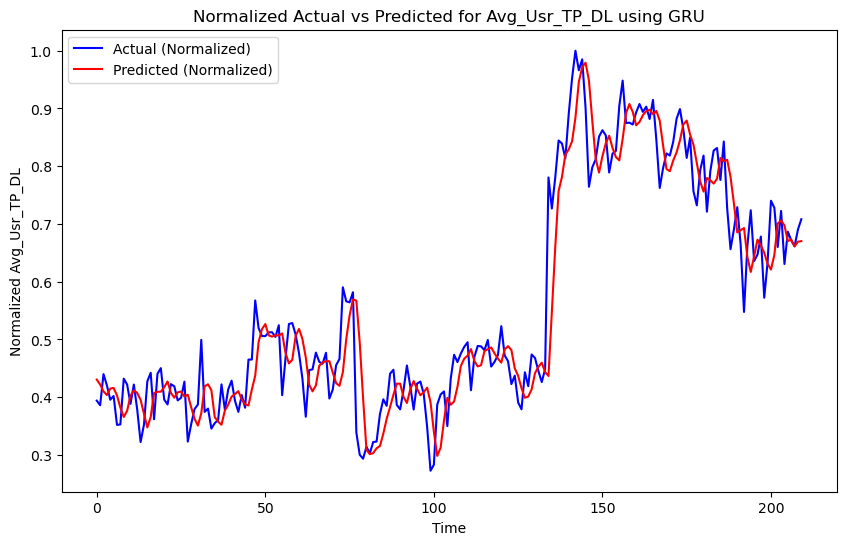

In [16]:
# Function to create dataset matrix for GRU
def create_dataset_gru(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'Avg_Usr_TP_DL'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.42)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for GRU (look_back=3)
look_back = 3
X_train, y_train = create_dataset_gru(train, look_back=look_back)
X_test, y_test = create_dataset_gru(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for GRU
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 1))
gru_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train)
test_predict_gru = gru_model.predict(X_test)

# Calculate MSE for the GRU model
gru_mse = mean_squared_error(y_test, test_predict_gru)
print(f'GRU Model MSE (Normalized): {gru_mse}')

# Calculate R-squared value
from sklearn.metrics import r2_score
gru_r2 = r2_score(y_test, test_predict_gru)
print(f'GRU Model R-squared (Normalized): {gru_r2}')

# Plot the GRU model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using GRU')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()


Training with 10% of data:
11/11 [==============================] - 1s 3ms/step
MSE: 0.0550, R-squared: -0.3811

Training with 20% of data:
10/10 [==============================] - 1s 3ms/step
MSE: 0.0355, R-squared: -0.8986

Training with 30% of data:
8/8 [==============================] - 1s 3ms/step
MSE: 0.0044, R-squared: 0.6722

Training with 40% of data:
7/7 [==============================] - 1s 3ms/step
MSE: 0.0043, R-squared: 0.5171

Training with 42% of data:
7/7 [==============================] - 1s 3ms/step
MSE: 0.0043, R-squared: 0.5091

Training with 45% of data:
7/7 [==============================] - 1s 3ms/step
MSE: 0.0046, R-squared: 0.4631

Training with 50% of data:
6/6 [==============================] - 1s 3ms/step
MSE: 0.0049, R-squared: 0.4534

Training with 60% of data:
5/5 [==============================] - 1s 3ms/step
MSE: 0.0060, R-squared: 0.4551

Training with 70% of data:
4/4 [==============================] - 1s 4ms/step
MSE: 0.0045, R-squared: 0.6064

Tra

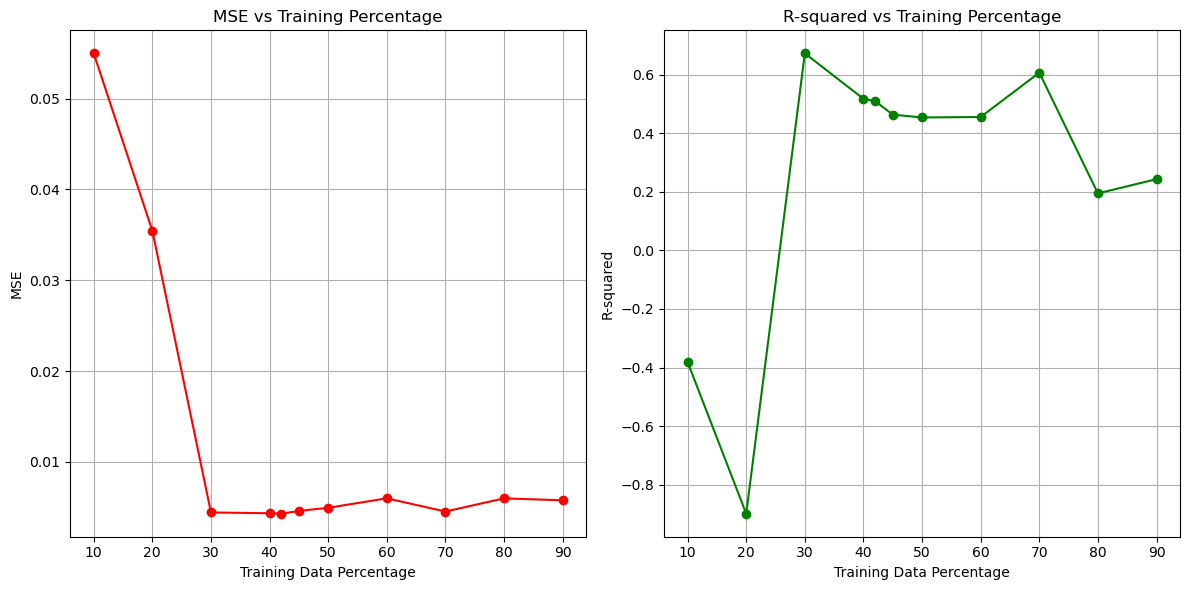

In [18]:

# Function to create dataset matrix for GRU
def create_dataset_gru(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Function to build the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Load your dataset
# Assuming 'data' is a Pandas DataFrame already loaded
# 'Avg_Usr_TP_DL' with actual file and feature name
feature = 'Avg_Usr'

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Set look_back parameter
look_back = 3

# List of training percentages
train_percentages = [10, 20, 30, 40, 42, 45, 50, 60, 70, 80, 90]

# Initialize results dictionary
results = {'train_percentage': [], 'mse': [], 'r2': []}

# Loop through training percentages
for percent in train_percentages:
    print(f"\nTraining with {percent}% of data:")
    
    # Split data into training and test sets
    train_size = int(len(scaled_data) * (percent / 100))
    train, test = scaled_data[:train_size], scaled_data[train_size:]
    
    # Prepare data for GRU
    X_train, y_train = create_dataset_gru(train, look_back=look_back)
    X_test, y_test = create_dataset_gru(test, look_back=look_back)
    
    # Reshape input to fit GRU model
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
    
    # Build and train GRU model
    gru_model = build_gru_model((look_back, 1))
    gru_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)
    
    # Predict and calculate metrics
    test_predict_gru = gru_model.predict(X_test)
    mse = mean_squared_error(y_test, test_predict_gru)
    r2 = r2_score(y_test, test_predict_gru)
    
    # Store results
    results['train_percentage'].append(percent)
    results['mse'].append(mse)
    results['r2'].append(r2)
    
    # Print metrics
    print(f"MSE: {mse:.4f}, R-squared: {r2:.4f}")

# Plot MSE and R-squared against training percentages
plt.figure(figsize=(12, 6))

# MSE Plot
plt.subplot(1, 2, 1)
plt.plot(results['train_percentage'], results['mse'], marker='o', color='red')
plt.title('MSE vs Training Percentage')
plt.xlabel('Training Data Percentage')
plt.ylabel('MSE')
plt.grid()

# R-squared Plot
plt.subplot(1, 2, 2)
plt.plot(results['train_percentage'], results['r2'], marker='o', color='green')
plt.title('R-squared vs Training Percentage')
plt.xlabel('Training Data Percentage')
plt.ylabel('R-squared')
plt.grid()

plt.tight_layout()
plt.show()



Training with 10% of data:
11/11 [==============================] - 1s 3ms/step
MSE: 0.05752196, R-squared: -0.44491513

Training with 20% of data:
10/10 [==============================] - 1s 3ms/step
MSE: 0.03720777, R-squared: -0.99257424

Training with 30% of data:
8/8 [==============================] - 1s 3ms/step
MSE: 0.00431896, R-squared: 0.68076730

Training with 40% of data:
7/7 [==============================] - 1s 3ms/step
MSE: 0.00455040, R-squared: 0.49424086

Training with 42% of data:
7/7 [==============================] - 1s 3ms/step
MSE: 0.00472501, R-squared: 0.46011354

Training with 45% of data:
7/7 [==============================] - 1s 3ms/step
MSE: 0.00495323, R-squared: 0.42222809

Training with 50% of data:
6/6 [==============================] - 1s 3ms/step
MSE: 0.00519194, R-squared: 0.42618799

Training with 60% of data:
5/5 [==============================] - 1s 3ms/step
MSE: 0.00609059, R-squared: 0.44574738

Training with 70% of data:
4/4 [=================

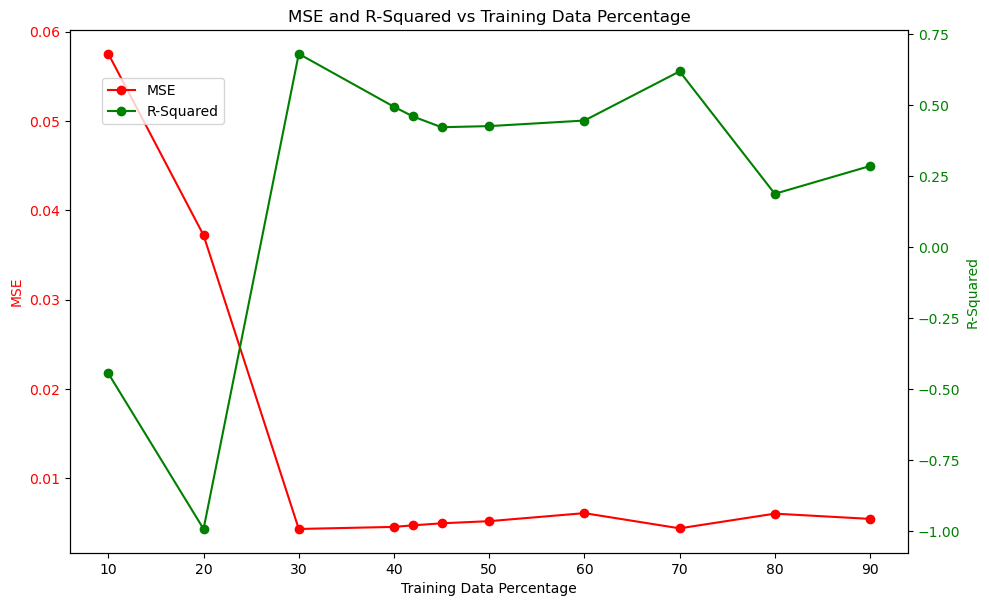

In [19]:

# Function to create dataset matrix for GRU
def create_dataset_gru(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Function to build the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Load dataset
feature = 'Avg_Usr'  # Replace with your feature name

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Set parameters
look_back = 3
train_percentages = [10, 20, 30, 40, 42, 45, 50, 60, 70, 80, 90]

# Initialize results dictionary
results = {'Train (%)': [], 'MSE': [], 'R-Squared': []}

# Loop through training percentages
for percent in train_percentages:
    print(f"\nTraining with {percent}% of data:")
    
    # Split data
    train_size = int(len(scaled_data) * (percent / 100))
    train, test = scaled_data[:train_size], scaled_data[train_size:]
    
    # Prepare dataset
    X_train, y_train = create_dataset_gru(train, look_back=look_back)
    X_test, y_test = create_dataset_gru(test, look_back=look_back)
    
    # Reshape input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
    
    # Build and train model
    gru_model = build_gru_model((look_back, 1))
    gru_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)
    
    # Predict and evaluate
    test_predict_gru = gru_model.predict(X_test)
    mse = mean_squared_error(y_test, test_predict_gru)
    r2 = r2_score(y_test, test_predict_gru)
    
    # Store results
    results['Train (%)'].append(percent)
    results['MSE'].append(mse)
    results['R-Squared'].append(r2)
    
    # Print results for this iteration
    print(f"MSE: {mse:.8f}, R-squared: {r2:.8f}")

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Print tabular results
print("\nResults in Tabular Format:")
print(results_df)

# Plot MSE and R-Squared in a single figure
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot MSE
ax1.set_xlabel('Training Data Percentage')
ax1.set_ylabel('MSE', color='red')
ax1.plot(results_df['Train (%)'], results_df['MSE'], marker='o', color='red', label='MSE')
ax1.tick_params(axis='y', labelcolor='red')

# Add R-Squared on the same plot
ax2 = ax1.twinx()
ax2.set_ylabel('R-Squared', color='green')
ax2.plot(results_df['Train (%)'], results_df['R-Squared'], marker='o', color='green', label='R-Squared')
ax2.tick_params(axis='y', labelcolor='green')

# Title and legends
fig.tight_layout()
plt.title('MSE and R-Squared vs Training Data Percentage')
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.show()



Training with 10% of data:
11/11 [==============================] - 1s 2ms/step
MSE: 0.03899380, R-squared: -0.39932504

Training with 20% of data:
10/10 [==============================] - 1s 3ms/step
MSE: 0.04866403, R-squared: -1.34079026

Training with 30% of data:
8/8 [==============================] - 1s 3ms/step
MSE: 0.00395561, R-squared: 0.81235446

Training with 40% of data:
7/7 [==============================] - 1s 3ms/step
MSE: 0.00269252, R-squared: 0.86761879

Training with 42% of data:
7/7 [==============================] - 1s 3ms/step
MSE: 0.00215571, R-squared: 0.89510782

Training with 45% of data:
7/7 [==============================] - 1s 3ms/step
MSE: 0.00307369, R-squared: 0.85245846

Training with 50% of data:
6/6 [==============================] - 1s 3ms/step
MSE: 0.00226884, R-squared: 0.89543143

Training with 60% of data:
5/5 [==============================] - 1s 3ms/step
MSE: 0.00358409, R-squared: 0.84741059

Training with 70% of data:
4/4 [=================

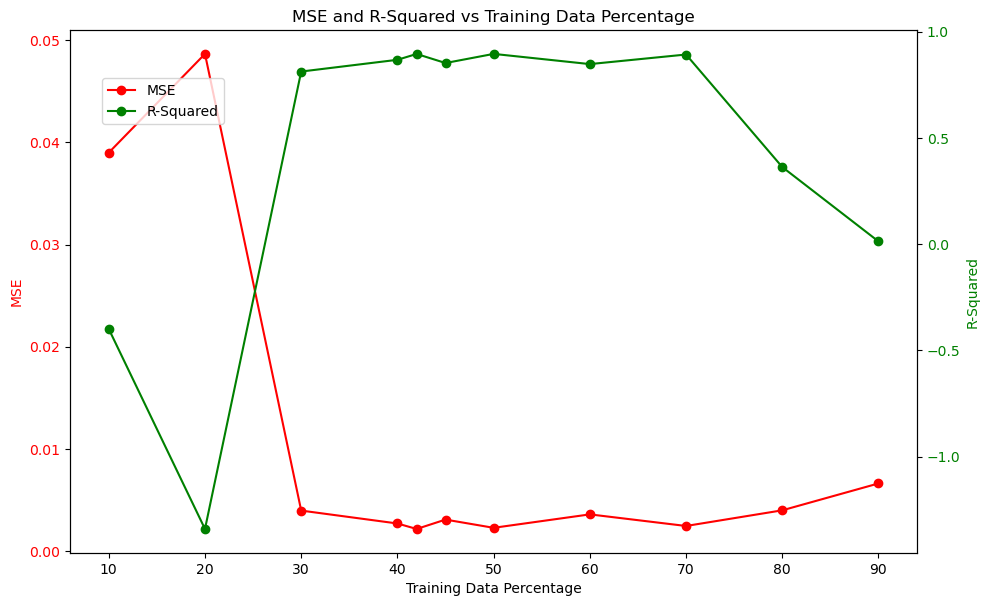

In [20]:

# Function to create dataset matrix for GRU
def create_dataset_gru(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Function to build the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Load dataset
feature = 'DL_TRAFFIC_MB'  # Replace with your feature name

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Set parameters
look_back = 3
train_percentages = [10, 20, 30, 40, 42, 45, 50, 60, 70, 80, 90]

# Initialize results dictionary
results = {'Train (%)': [], 'MSE': [], 'R-Squared': []}

# Loop through training percentages
for percent in train_percentages:
    print(f"\nTraining with {percent}% of data:")
    
    # Split data
    train_size = int(len(scaled_data) * (percent / 100))
    train, test = scaled_data[:train_size], scaled_data[train_size:]
    
    # Prepare dataset
    X_train, y_train = create_dataset_gru(train, look_back=look_back)
    X_test, y_test = create_dataset_gru(test, look_back=look_back)
    
    # Reshape input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
    
    # Build and train model
    gru_model = build_gru_model((look_back, 1))
    gru_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)
    
    # Predict and evaluate
    test_predict_gru = gru_model.predict(X_test)
    mse = mean_squared_error(y_test, test_predict_gru)
    r2 = r2_score(y_test, test_predict_gru)
    
    # Store results
    results['Train (%)'].append(percent)
    results['MSE'].append(mse)
    results['R-Squared'].append(r2)
    
    # Print results for this iteration
    print(f"MSE: {mse:.8f}, R-squared: {r2:.8f}")

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Print tabular results
print("\nResults in Tabular Format:")
print(results_df)

# Plot MSE and R-Squared in a single figure
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot MSE
ax1.set_xlabel('Training Data Percentage')
ax1.set_ylabel('MSE', color='red')
ax1.plot(results_df['Train (%)'], results_df['MSE'], marker='o', color='red', label='MSE')
ax1.tick_params(axis='y', labelcolor='red')

# Add R-Squared on the same plot
ax2 = ax1.twinx()
ax2.set_ylabel('R-Squared', color='green')
ax2.plot(results_df['Train (%)'], results_df['R-Squared'], marker='o', color='green', label='R-Squared')
ax2.tick_params(axis='y', labelcolor='green')

# Title and legends
fig.tight_layout()
plt.title('MSE and R-Squared vs Training Data Percentage')
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.show()



Training with 10% of data:
11/11 [==============================] - 2s 3ms/step
MSE: 0.06718934, R-squared: -0.39612008

Training with 20% of data:
10/10 [==============================] - 1s 3ms/step
MSE: 0.03379303, R-squared: 0.02996997

Training with 30% of data:
8/8 [==============================] - 1s 5ms/step
MSE: 0.00420916, R-squared: 0.87623285

Training with 40% of data:
7/7 [==============================] - 2s 3ms/step
MSE: 0.00384408, R-squared: 0.89503159

Training with 42% of data:
7/7 [==============================] - 2s 3ms/step
MSE: 0.00391370, R-squared: 0.89503283

Training with 45% of data:
7/7 [==============================] - 2s 3ms/step
MSE: 0.00423338, R-squared: 0.88804420

Training with 50% of data:
6/6 [==============================] - 1s 3ms/step
MSE: 0.00423104, R-squared: 0.88915460

Training with 60% of data:
5/5 [==============================] - 1s 2ms/step
MSE: 0.00463127, R-squared: 0.88619640

Training with 70% of data:
4/4 [==================

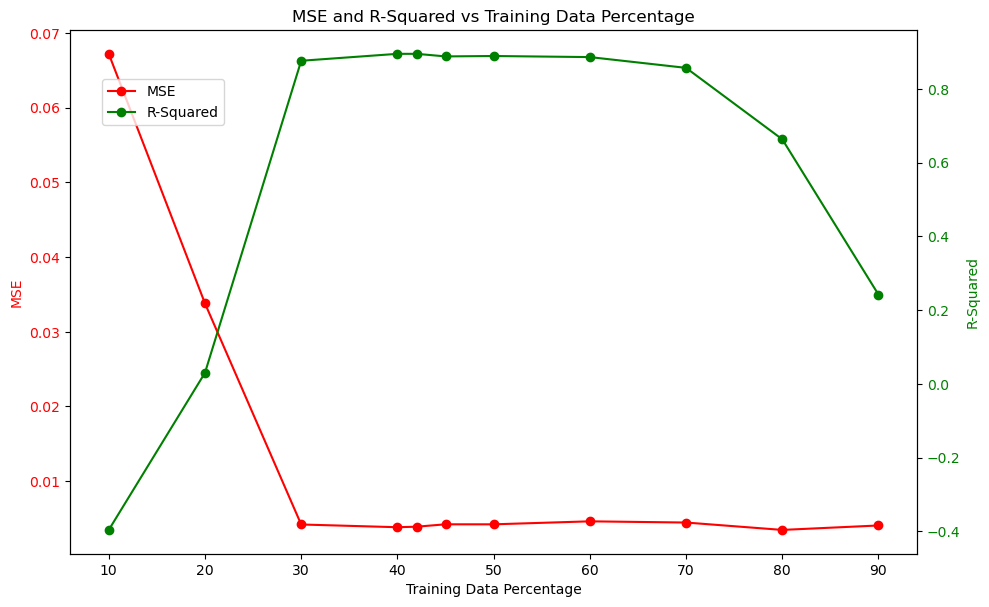

In [21]:

# Function to create dataset matrix for GRU
def create_dataset_gru(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Function to build the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Load dataset
feature = 'Avg_Usr_TP_DL'  # Replace with your feature name

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Set parameters
look_back = 3
train_percentages = [10, 20, 30, 40, 42, 45, 50, 60, 70, 80, 90]

# Initialize results dictionary
results = {'Train (%)': [], 'MSE': [], 'R-Squared': []}

# Loop through training percentages
for percent in train_percentages:
    print(f"\nTraining with {percent}% of data:")
    
    # Split data
    train_size = int(len(scaled_data) * (percent / 100))
    train, test = scaled_data[:train_size], scaled_data[train_size:]
    
    # Prepare dataset
    X_train, y_train = create_dataset_gru(train, look_back=look_back)
    X_test, y_test = create_dataset_gru(test, look_back=look_back)
    
    # Reshape input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
    
    # Build and train model
    gru_model = build_gru_model((look_back, 1))
    gru_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)
    
    # Predict and evaluate
    test_predict_gru = gru_model.predict(X_test)
    mse = mean_squared_error(y_test, test_predict_gru)
    r2 = r2_score(y_test, test_predict_gru)
    
    # Store results
    results['Train (%)'].append(percent)
    results['MSE'].append(mse)
    results['R-Squared'].append(r2)
    
    # Print results for this iteration
    print(f"MSE: {mse:.8f}, R-squared: {r2:.8f}")

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Print tabular results
print("\nResults in Tabular Format:")
print(results_df)

# Plot MSE and R-Squared in a single figure
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot MSE
ax1.set_xlabel('Training Data Percentage')
ax1.set_ylabel('MSE', color='red')
ax1.plot(results_df['Train (%)'], results_df['MSE'], marker='o', color='red', label='MSE')
ax1.tick_params(axis='y', labelcolor='red')

# Add R-Squared on the same plot
ax2 = ax1.twinx()
ax2.set_ylabel('R-Squared', color='green')
ax2.plot(results_df['Train (%)'], results_df['R-Squared'], marker='o', color='green', label='R-Squared')
ax2.tick_params(axis='y', labelcolor='green')

# Title and legends
fig.tight_layout()
plt.title('MSE and R-Squared vs Training Data Percentage')
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.show()



Training with 10% of data:
11/11 [==============================] - 1s 3ms/step
MSE: 0.04255597, R-squared: -0.52715620

Training with 20% of data:
10/10 [==============================] - 1s 3ms/step
MSE: 0.05661483, R-squared: -1.72323188

Training with 30% of data:
8/8 [==============================] - 1s 3ms/step
MSE: 0.00962344, R-squared: 0.54348431

Training with 40% of data:
7/7 [==============================] - 1s 3ms/step
MSE: 0.00262167, R-squared: 0.87110218

Training with 42% of data:
7/7 [==============================] - 1s 3ms/step
MSE: 0.00243819, R-squared: 0.88136265

Training with 45% of data:
7/7 [==============================] - 1s 3ms/step
MSE: 0.00260707, R-squared: 0.87485710

Training with 50% of data:
6/6 [==============================] - 1s 4ms/step
MSE: 0.00280008, R-squared: 0.87094724

Training with 60% of data:
5/5 [==============================] - 1s 3ms/step
MSE: 0.00374642, R-squared: 0.84049951

Training with 70% of data:
4/4 [=================

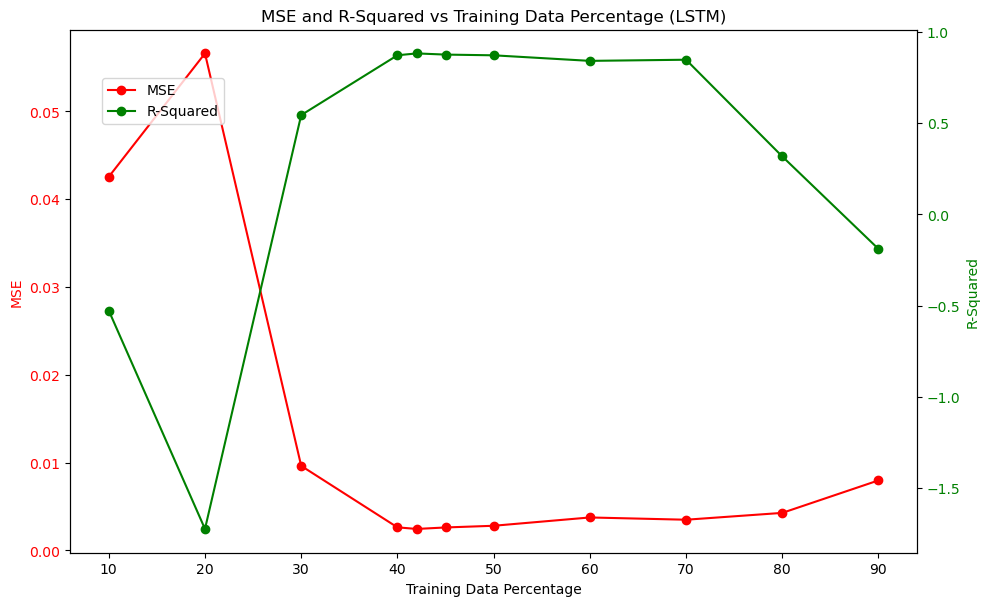

In [22]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Function to create dataset matrix for LSTM
def create_dataset_lstm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Function to build the LSTM model
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Load dataset
feature = 'DL_TRAFFIC_MB'  # Replace with your feature name

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Set parameters
look_back = 3
train_percentages = [10, 20, 30, 40, 42, 45, 50, 60, 70, 80, 90]

# Initialize results dictionary
results = {'Train (%)': [], 'MSE': [], 'R-Squared': []}

# Loop through training percentages
for percent in train_percentages:
    print(f"\nTraining with {percent}% of data:")
    
    # Split data
    train_size = int(len(scaled_data) * (percent / 100))
    train, test = scaled_data[:train_size], scaled_data[train_size:]
    
    # Prepare dataset
    X_train, y_train = create_dataset_lstm(train, look_back=look_back)
    X_test, y_test = create_dataset_lstm(test, look_back=look_back)
    
    # Reshape input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
    
    # Build and train model
    lstm_model = build_lstm_model((look_back, 1))
    lstm_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)
    
    # Predict and evaluate
    test_predict_lstm = lstm_model.predict(X_test)
    mse = mean_squared_error(y_test, test_predict_lstm)
    r2 = r2_score(y_test, test_predict_lstm)
    
    # Store results
    results['Train (%)'].append(percent)
    results['MSE'].append(mse)
    results['R-Squared'].append(r2)
    
    # Print results for this iteration
    print(f"MSE: {mse:.8f}, R-squared: {r2:.8f}")

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Print tabular results
print("\nResults in Tabular Format:")
print(results_df)

# Plot MSE and R-Squared in a single figure
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot MSE
ax1.set_xlabel('Training Data Percentage')
ax1.set_ylabel('MSE', color='red')
ax1.plot(results_df['Train (%)'], results_df['MSE'], marker='o', color='red', label='MSE')
ax1.tick_params(axis='y', labelcolor='red')

# Add R-Squared on the same plot
ax2 = ax1.twinx()
ax2.set_ylabel('R-Squared', color='green')
ax2.plot(results_df['Train (%)'], results_df['R-Squared'], marker='o', color='green', label='R-Squared')
ax2.tick_params(axis='y', labelcolor='green')

# Title and legends
fig.tight_layout()
plt.title('MSE and R-Squared vs Training Data Percentage (LSTM)')
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.show()



Training with 10% of data:
11/11 [==============================] - 1s 3ms/step
MSE: 0.10892629, R-squared: -1.73615921

Training with 20% of data:
10/10 [==============================] - 1s 3ms/step
MSE: 0.03567644, R-squared: -0.91056717

Training with 30% of data:
8/8 [==============================] - 1s 3ms/step
MSE: 0.01343437, R-squared: 0.00700872

Training with 40% of data:
7/7 [==============================] - 2s 3ms/step
MSE: 0.00725578, R-squared: 0.19354809

Training with 42% of data:
7/7 [==============================] - 1s 3ms/step
MSE: 0.00612435, R-squared: 0.30022220

Training with 45% of data:
7/7 [==============================] - 1s 3ms/step
MSE: 0.00657804, R-squared: 0.23270116

Training with 50% of data:
6/6 [==============================] - 1s 3ms/step
MSE: 0.00616894, R-squared: 0.31821098

Training with 60% of data:
5/5 [==============================] - 1s 3ms/step
MSE: 0.00767499, R-squared: 0.30156479

Training with 70% of data:
4/4 [=================

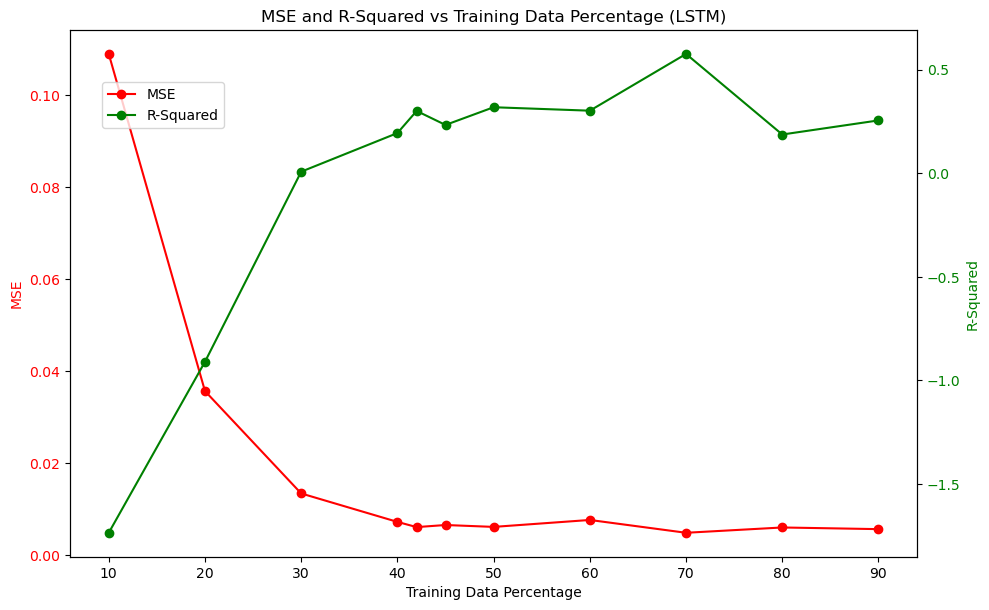

In [23]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Function to create dataset matrix for LSTM
def create_dataset_lstm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Function to build the LSTM model
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Load dataset
feature = 'Avg_Usr'  # Replace with your feature name

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Set parameters
look_back = 3
train_percentages = [10, 20, 30, 40, 42, 45, 50, 60, 70, 80, 90]

# Initialize results dictionary
results = {'Train (%)': [], 'MSE': [], 'R-Squared': []}

# Loop through training percentages
for percent in train_percentages:
    print(f"\nTraining with {percent}% of data:")
    
    # Split data
    train_size = int(len(scaled_data) * (percent / 100))
    train, test = scaled_data[:train_size], scaled_data[train_size:]
    
    # Prepare dataset
    X_train, y_train = create_dataset_lstm(train, look_back=look_back)
    X_test, y_test = create_dataset_lstm(test, look_back=look_back)
    
    # Reshape input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
    
    # Build and train model
    lstm_model = build_lstm_model((look_back, 1))
    lstm_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)
    
    # Predict and evaluate
    test_predict_lstm = lstm_model.predict(X_test)
    mse = mean_squared_error(y_test, test_predict_lstm)
    r2 = r2_score(y_test, test_predict_lstm)
    
    # Store results
    results['Train (%)'].append(percent)
    results['MSE'].append(mse)
    results['R-Squared'].append(r2)
    
    # Print results for this iteration
    print(f"MSE: {mse:.8f}, R-squared: {r2:.8f}")

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Print tabular results
print("\nResults in Tabular Format:")
print(results_df)

# Plot MSE and R-Squared in a single figure
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot MSE
ax1.set_xlabel('Training Data Percentage')
ax1.set_ylabel('MSE', color='red')
ax1.plot(results_df['Train (%)'], results_df['MSE'], marker='o', color='red', label='MSE')
ax1.tick_params(axis='y', labelcolor='red')

# Add R-Squared on the same plot
ax2 = ax1.twinx()
ax2.set_ylabel('R-Squared', color='green')
ax2.plot(results_df['Train (%)'], results_df['R-Squared'], marker='o', color='green', label='R-Squared')
ax2.tick_params(axis='y', labelcolor='green')

# Title and legends
fig.tight_layout()
plt.title('MSE and R-Squared vs Training Data Percentage (LSTM)')
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.show()



Training with 10% of data:
11/11 [==============================] - 1s 3ms/step
MSE: 0.08607095, R-squared: -0.78845884

Training with 20% of data:
10/10 [==============================] - 1s 3ms/step
MSE: 0.07154955, R-squared: -1.05383234

Training with 30% of data:
8/8 [==============================] - 1s 3ms/step
MSE: 0.00453374, R-squared: 0.86668892

Training with 40% of data:
7/7 [==============================] - 1s 3ms/step
MSE: 0.00533794, R-squared: 0.85423929

Training with 42% of data:
7/7 [==============================] - 1s 3ms/step
MSE: 0.00676683, R-squared: 0.81851051

Training with 45% of data:
7/7 [==============================] - 1s 3ms/step
MSE: 0.00662276, R-squared: 0.82485465

Training with 50% of data:
6/6 [==============================] - 1s 3ms/step
MSE: 0.00569880, R-squared: 0.85070200

Training with 60% of data:
5/5 [==============================] - 1s 3ms/step
MSE: 0.00597019, R-squared: 0.85329516

Training with 70% of data:
4/4 [=================

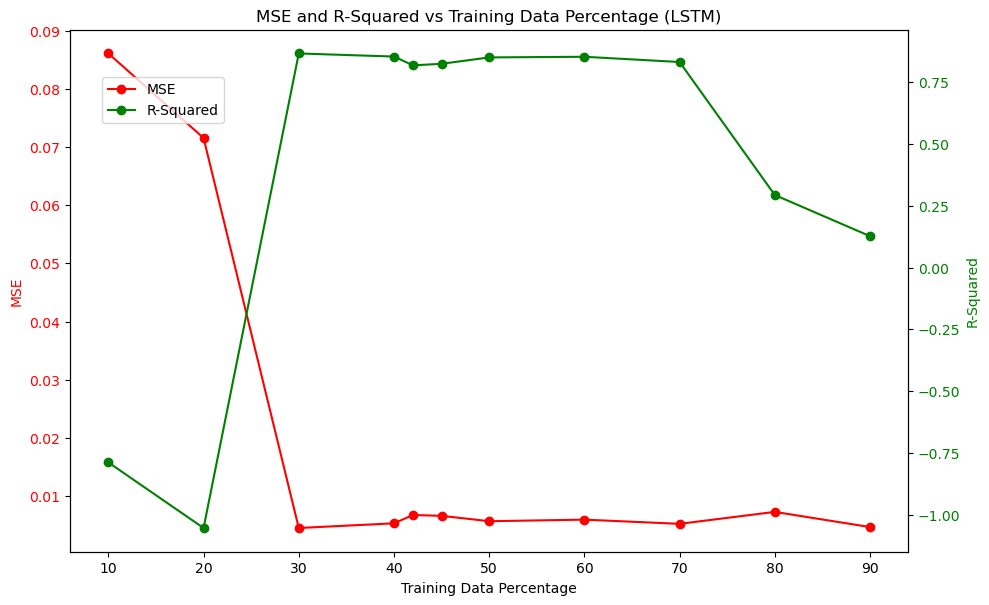

In [24]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Function to create dataset matrix for LSTM
def create_dataset_lstm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Function to build the LSTM model
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Load dataset
feature = 'Avg_Usr_TP_DL'  # Replace with your feature name

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Set parameters
look_back = 3
train_percentages = [10, 20, 30, 40, 42, 45, 50, 60, 70, 80, 90]

# Initialize results dictionary
results = {'Train (%)': [], 'MSE': [], 'R-Squared': []}

# Loop through training percentages
for percent in train_percentages:
    print(f"\nTraining with {percent}% of data:")
    
    # Split data
    train_size = int(len(scaled_data) * (percent / 100))
    train, test = scaled_data[:train_size], scaled_data[train_size:]
    
    # Prepare dataset
    X_train, y_train = create_dataset_lstm(train, look_back=look_back)
    X_test, y_test = create_dataset_lstm(test, look_back=look_back)
    
    # Reshape input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
    
    # Build and train model
    lstm_model = build_lstm_model((look_back, 1))
    lstm_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)
    
    # Predict and evaluate
    test_predict_lstm = lstm_model.predict(X_test)
    mse = mean_squared_error(y_test, test_predict_lstm)
    r2 = r2_score(y_test, test_predict_lstm)
    
    # Store results
    results['Train (%)'].append(percent)
    results['MSE'].append(mse)
    results['R-Squared'].append(r2)
    
    # Print results for this iteration
    print(f"MSE: {mse:.8f}, R-squared: {r2:.8f}")

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Print tabular results
print("\nResults in Tabular Format:")
print(results_df)

# Plot MSE and R-Squared in a single figure
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot MSE
ax1.set_xlabel('Training Data Percentage')
ax1.set_ylabel('MSE', color='red')
ax1.plot(results_df['Train (%)'], results_df['MSE'], marker='o', color='red', label='MSE')
ax1.tick_params(axis='y', labelcolor='red')

# Add R-Squared on the same plot
ax2 = ax1.twinx()
ax2.set_ylabel('R-Squared', color='green')
ax2.plot(results_df['Train (%)'], results_df['R-Squared'], marker='o', color='green', label='R-Squared')
ax2.tick_params(axis='y', labelcolor='green')

# Title and legends
fig.tight_layout()
plt.title('MSE and R-Squared vs Training Data Percentage (LSTM)')
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.show()


Training with kernel=rbf, C=10, gamma=auto, epsilon=0.01
Training with kernel=rbf, C=10, gamma=auto, epsilon=0.1
Best MSE (normalized): 0.004168105442590126 with params: {'kernel': 'rbf', 'C': 10, 'gamma': 'auto', 'epsilon': 0.01}

Evaluation Metrics:
Mean Absolute Error (MAE): 0.04711294174484453
Root Mean Squared Error (RMSE): 0.06456086618525286
Mean Absolute Percentage Error (MAPE): 6.882463461301402%
R-squared (R2): 0.6382142788412416
Forward Bias: -0.009692859686666572


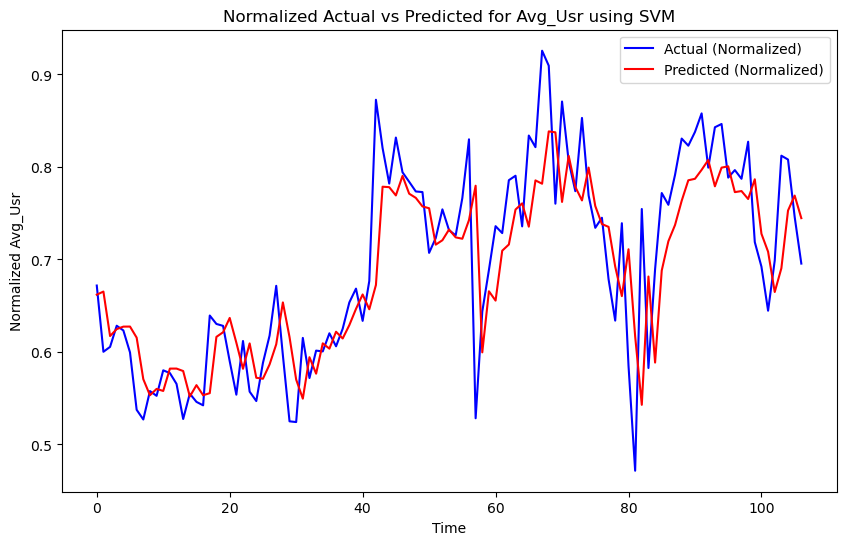

In [30]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to a 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'Avg_Usr'

# Normalize the 'Avg_Usr' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.7)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train, y_train = create_dataset_svm(train, look_back=look_back)
X_test, y_test = create_dataset_svm(test, look_back=look_back)

# Train SVM model with different hyperparameters
best_mse = float('inf')
best_params = {}
best_model = None

# List to store results
results = []

# Hyperparameter tuning loop for SVM
for kernel in ['rbf']:
    for C in [10]:
        for gamma in ['auto']:
            for epsilon in [0.01, 0.1]:
                print(f'Training with kernel={kernel}, C={C}, gamma={gamma}, epsilon={epsilon}')
                svm_model = SVR(kernel=kernel, C=C, gamma=gamma, epsilon=epsilon)
                svm_model.fit(X_train, y_train)
                
                # Predict and calculate metrics
                test_predict = svm_model.predict(X_test)
                mse = mean_squared_error(y_test, test_predict)
                r_squared = r2_score(y_test, test_predict)

                # Append results
                results.append({
                    'Kernel': kernel,
                    'C': C,
                    'Gamma': gamma,
                    'Epsilon': epsilon,
                    'MSE': mse,
                    'R-squared': r_squared
                })

                # Track the best model based on MSE
                if mse < best_mse:
                    best_mse = mse
                    best_params = {'kernel': kernel, 'C': C, 'gamma': gamma, 'epsilon': epsilon}
                    best_model = svm_model

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Export results to Excel
results_df.to_excel('svm_hyperparameter_results.xlsx', index=False)

print(f'Best MSE (normalized): {best_mse} with params: {best_params}')

# Predict with the best model
best_test_predict = best_model.predict(X_test)

# Calculate additional evaluation metrics
mae = mean_absolute_error(y_test, best_test_predict)
rmse = np.sqrt(mean_squared_error(y_test, best_test_predict))
mape = np.mean(np.abs((y_test - best_test_predict) / y_test)) * 100
r_squared = r2_score(y_test, best_test_predict)
forward_bias = np.mean(best_test_predict - y_test)

# Print metrics
print("\nEvaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")
print(f"R-squared (R2): {r_squared}")
print(f"Forward Bias: {forward_bias}")

# Plot the best model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(best_test_predict, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using SVM')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()



Training with 10% of data:
MSE: 0.11501085, R-squared: -1.88899962

Training with 20% of data:
MSE: 0.12475262, R-squared: -5.68083108

Training with 30% of data:
MSE: 0.01827681, R-squared: -0.35091658

Training with 40% of data:
MSE: 0.00927117, R-squared: -0.03045483

Training with 42% of data:
MSE: 0.00771918, R-squared: 0.11799436

Training with 45% of data:
MSE: 0.00608066, R-squared: 0.29071878

Training with 50% of data:
MSE: 0.00436228, R-squared: 0.51788186

Training with 60% of data:
MSE: 0.00494453, R-squared: 0.55004106

Training with 70% of data:
MSE: 0.00416811, R-squared: 0.63821428

Training with 72% of data:
MSE: 0.00462126, R-squared: 0.60434554

Training with 75% of data:
MSE: 0.00505344, R-squared: 0.50873947

Training with 80% of data:
MSE: 0.00602650, R-squared: 0.18883238

Training with 90% of data:
MSE: 0.00566880, R-squared: 0.25638115

Results in Tabular Format:
    Train (%)       MSE  R-Squared
0          10  0.115011  -1.889000
1          20  0.124753  -5

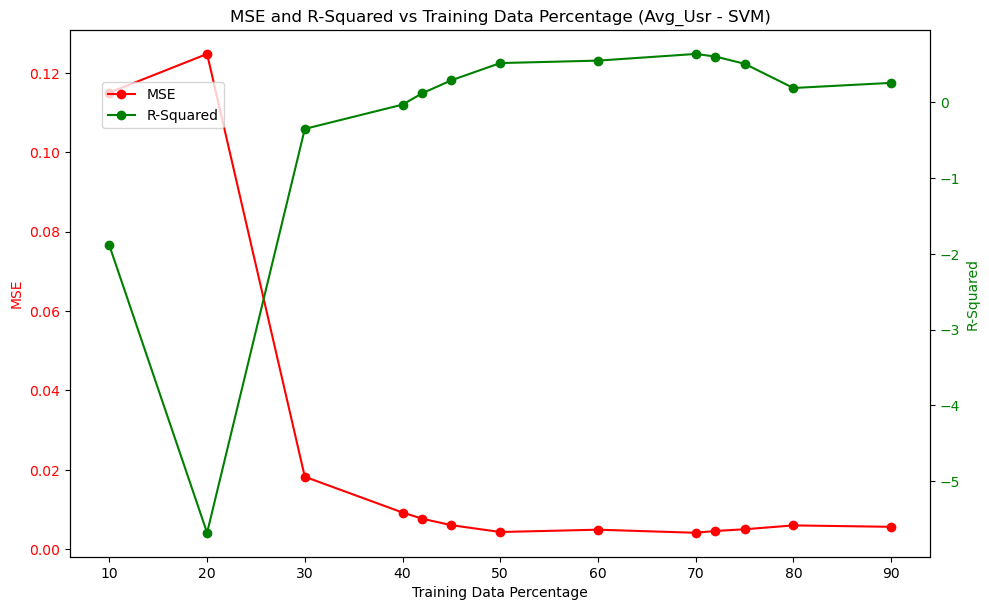

In [33]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to a 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'Avg_Usr'

# Normalize the 'Avg_Usr' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Parameters
look_back = 3
train_percentages = [10, 20, 30, 40, 42, 45, 50, 60, 70,72, 75, 80, 90]

# Initialize results list
results = []

# Train and evaluate SVM for different train percentages
for percent in train_percentages:
    print(f"\nTraining with {percent}% of data:")
    
    # Split data based on percentage
    train_size = int(len(scaled_data) * (percent / 100))
    train, test = scaled_data[:train_size], scaled_data[train_size:]
    
    # Create dataset
    X_train, y_train = create_dataset_svm(train, look_back=look_back)
    X_test, y_test = create_dataset_svm(test, look_back=look_back)
    
    # Train SVM model with fixed hyperparameters
    svm_model = SVR(kernel='rbf', C=10, gamma='auto', epsilon=0.01)
    svm_model.fit(X_train, y_train)
    
    # Predict and evaluate
    test_predict = svm_model.predict(X_test)
    mse = mean_squared_error(y_test, test_predict)
    r_squared = r2_score(y_test, test_predict)
    
    # Append results
    results.append({
        'Train (%)': percent,
        'MSE': mse,
        'R-Squared': r_squared
    })
    print(f"MSE: {mse:.8f}, R-squared: {r_squared:.8f}")

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Export results to Excel
results_df.to_excel('svm_train_percentage_results.xlsx', index=False)

# Print tabular results
print("\nResults in Tabular Format:")
print(results_df)

# Plot MSE and R-Squared in a single figure
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot MSE
ax1.set_xlabel('Training Data Percentage')
ax1.set_ylabel('MSE', color='red')
ax1.plot(results_df['Train (%)'], results_df['MSE'], marker='o', color='red', label='MSE')
ax1.tick_params(axis='y', labelcolor='red')

# Add R-Squared on the same plot
ax2 = ax1.twinx()
ax2.set_ylabel('R-Squared', color='green')
ax2.plot(results_df['Train (%)'], results_df['R-Squared'], marker='o', color='green', label='R-Squared')
ax2.tick_params(axis='y', labelcolor='green')

# Title and legends
fig.tight_layout()
plt.title(f'MSE and R-Squared vs Training Data Percentage ({feature} - SVM)')
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.show()



Training with 10% of data:
MSE: 0.06196091, R-squared: -0.28747892

Training with 20% of data:
MSE: 0.03054103, R-squared: 0.12331867

Training with 30% of data:
MSE: 0.01907060, R-squared: 0.43924347

Training with 40% of data:
MSE: 0.01388482, R-squared: 0.62085365

Training with 42% of data:
MSE: 0.01340102, R-squared: 0.64057854

Training with 45% of data:
MSE: 0.01719597, R-squared: 0.54523622

Training with 50% of data:
MSE: 0.01949100, R-squared: 0.48937200

Training with 60% of data:
MSE: 0.01215818, R-squared: 0.70123848

Training with 70% of data:
MSE: 0.01741052, R-squared: 0.44301629

Training with 80% of data:
MSE: 0.01935572, R-squared: -0.87184252

Training with 90% of data:
MSE: 0.00389394, R-squared: 0.27604436

Results in Tabular Format:
    Train (%)       MSE  R-Squared
0          10  0.061961  -0.287479
1          20  0.030541   0.123319
2          30  0.019071   0.439243
3          40  0.013885   0.620854
4          42  0.013401   0.640579
5          45  0.017196

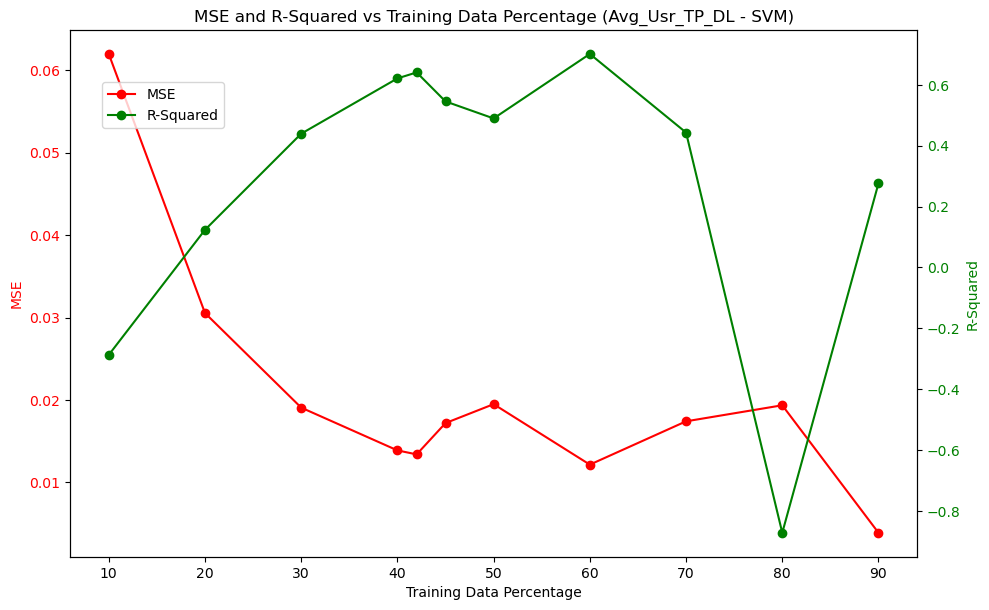

In [34]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to a 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'Avg_Usr_TP_DL'

# Normalize the 'Avg_Usr' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Parameters
look_back = 3
train_percentages = [10, 20, 30, 40, 42, 45, 50, 60, 70, 80, 90]

# Initialize results list
results = []

# Train and evaluate SVM for different train percentages
for percent in train_percentages:
    print(f"\nTraining with {percent}% of data:")
    
    # Split data based on percentage
    train_size = int(len(scaled_data) * (percent / 100))
    train, test = scaled_data[:train_size], scaled_data[train_size:]
    
    # Create dataset
    X_train, y_train = create_dataset_svm(train, look_back=look_back)
    X_test, y_test = create_dataset_svm(test, look_back=look_back)
    
    # Train SVM model with fixed hyperparameters
    svm_model = SVR(kernel='rbf', C=10, gamma='auto', epsilon=0.01)
    svm_model.fit(X_train, y_train)
    
    # Predict and evaluate
    test_predict = svm_model.predict(X_test)
    mse = mean_squared_error(y_test, test_predict)
    r_squared = r2_score(y_test, test_predict)
    
    # Append results
    results.append({
        'Train (%)': percent,
        'MSE': mse,
        'R-Squared': r_squared
    })
    print(f"MSE: {mse:.8f}, R-squared: {r_squared:.8f}")

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Export results to Excel
results_df.to_excel('svm_train_percentage_results.xlsx', index=False)

# Print tabular results
print("\nResults in Tabular Format:")
print(results_df)

# Plot MSE and R-Squared in a single figure
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot MSE
ax1.set_xlabel('Training Data Percentage')
ax1.set_ylabel('MSE', color='red')
ax1.plot(results_df['Train (%)'], results_df['MSE'], marker='o', color='red', label='MSE')
ax1.tick_params(axis='y', labelcolor='red')

# Add R-Squared on the same plot
ax2 = ax1.twinx()
ax2.set_ylabel('R-Squared', color='green')
ax2.plot(results_df['Train (%)'], results_df['R-Squared'], marker='o', color='green', label='R-Squared')
ax2.tick_params(axis='y', labelcolor='green')

# Title and legends
fig.tight_layout()
plt.title(f'MSE and R-Squared vs Training Data Percentage ({feature} - SVM)')
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.show()



Training with 10% of data:
MSE: 0.10317610, R-squared: -2.70256004

Training with 20% of data:
MSE: 0.05079643, R-squared: -1.44336067

Training with 30% of data:
MSE: 0.01239501, R-squared: 0.41200732

Training with 40% of data:
MSE: 0.00864355, R-squared: 0.57502923

Training with 42% of data:
MSE: 0.00826148, R-squared: 0.59801328

Training with 45% of data:
MSE: 0.00408579, R-squared: 0.80387641

Training with 50% of data:
MSE: 0.00203971, R-squared: 0.90599194

Training with 60% of data:
MSE: 0.00232548, R-squared: 0.90099466

Training with 70% of data:
MSE: 0.00406444, R-squared: 0.82147138

Training with 80% of data:
MSE: 0.00769094, R-squared: -0.23073895

Training with 90% of data:
MSE: 0.00380419, R-squared: 0.43210155

Results in Tabular Format:
    Train (%)       MSE  R-Squared
0          10  0.103176  -2.702560
1          20  0.050796  -1.443361
2          30  0.012395   0.412007
3          40  0.008644   0.575029
4          42  0.008261   0.598013
5          45  0.00408

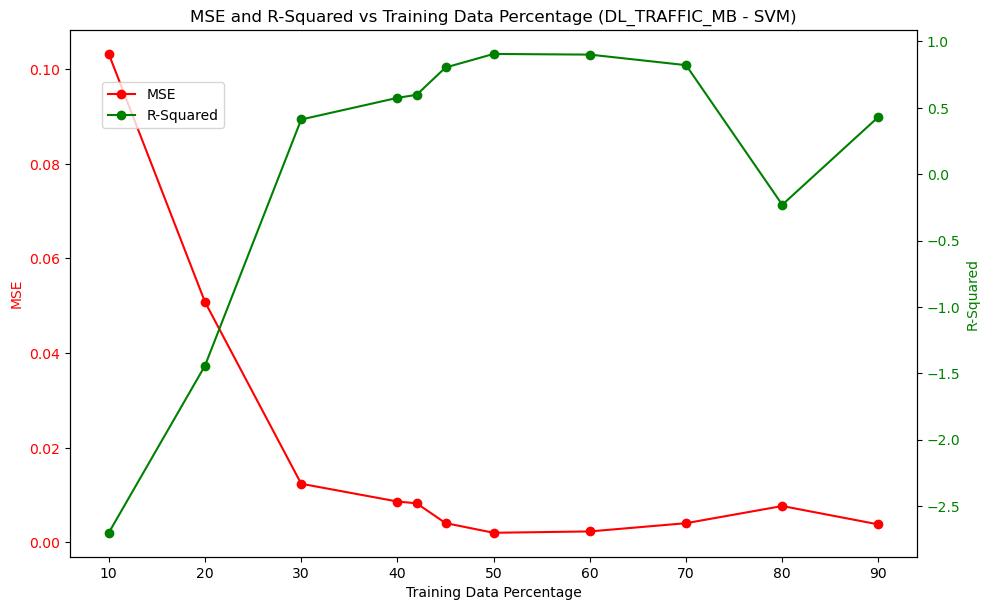

In [35]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to a 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'DL_TRAFFIC_MB'

# Normalize the 'Avg_Usr' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Parameters
look_back = 3
train_percentages = [10, 20, 30, 40, 42, 45, 50, 60, 70, 80, 90]

# Initialize results list
results = []

# Train and evaluate SVM for different train percentages
for percent in train_percentages:
    print(f"\nTraining with {percent}% of data:")
    
    # Split data based on percentage
    train_size = int(len(scaled_data) * (percent / 100))
    train, test = scaled_data[:train_size], scaled_data[train_size:]
    
    # Create dataset
    X_train, y_train = create_dataset_svm(train, look_back=look_back)
    X_test, y_test = create_dataset_svm(test, look_back=look_back)
    
    # Train SVM model with fixed hyperparameters
    svm_model = SVR(kernel='rbf', C=10, gamma='auto', epsilon=0.01)
    svm_model.fit(X_train, y_train)
    
    # Predict and evaluate
    test_predict = svm_model.predict(X_test)
    mse = mean_squared_error(y_test, test_predict)
    r_squared = r2_score(y_test, test_predict)
    
    # Append results
    results.append({
        'Train (%)': percent,
        'MSE': mse,
        'R-Squared': r_squared
    })
    print(f"MSE: {mse:.8f}, R-squared: {r_squared:.8f}")

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Export results to Excel
results_df.to_excel('svm_train_percentage_results.xlsx', index=False)

# Print tabular results
print("\nResults in Tabular Format:")
print(results_df)

# Plot MSE and R-Squared in a single figure
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot MSE
ax1.set_xlabel('Training Data Percentage')
ax1.set_ylabel('MSE', color='red')
ax1.plot(results_df['Train (%)'], results_df['MSE'], marker='o', color='red', label='MSE')
ax1.tick_params(axis='y', labelcolor='red')

# Add R-Squared on the same plot
ax2 = ax1.twinx()
ax2.set_ylabel('R-Squared', color='green')
ax2.plot(results_df['Train (%)'], results_df['R-Squared'], marker='o', color='green', label='R-Squared')
ax2.tick_params(axis='y', labelcolor='green')

# Title and legends
fig.tight_layout()
plt.title(f'MSE and R-Squared vs Training Data Percentage ({feature} - SVM)')
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.show()



Training with 10% of data:


C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood op

MSE: 0.00340329, R-squared: 0.91833035

Training with 20% of data:


C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood op

MSE: 0.00348557, R-squared: 0.83034417

Training with 30% of data:


...

MSE: 0.00411883, R-squared: 0.51833538

Training with 50% of data:


C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MSE: 0.00452032, R-squared: 0.49389124

Training with 60% of data:


C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MSE: 0.00534522, R-squared: 0.50366292

Training with 70% of data:
MSE: 0.00505827, R-squared: 0.57236299

Training with 80% of data:
MSE: 0.00553452, R-squared: 0.30189958

Training with 90% of data:
MSE: 0.00589204, R-squared: 0.21400293

Results in Tabular Format:
    Train (%)       MSE  R-Squared
0          10  0.003403   0.918330
1          20  0.003486   0.830344
2          30  0.003619   0.740965
3          40  0.003939   0.568463
4          42  0.003974   0.555580
5          45  0.004119   0.518335
6          50  0.004520   0.493891
7          60  0.005345   0.503663
8          70  0.005058   0.572363
9          80  0.005535   0.301900
10         90  0.005892   0.214003


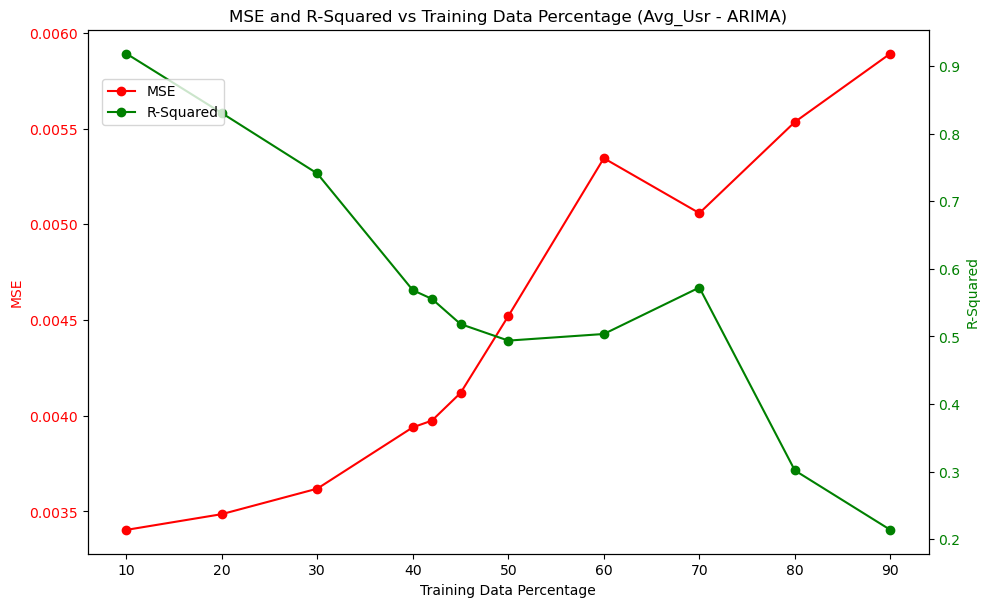

In [36]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Function to evaluate ARIMA model
def evaluate_arima(train, test, order):
    history = list(train)  # Initialize with training data
    predictions = []

    # Predict step by step
    for t in range(len(test)):
        model = ARIMA(history, order=order)
        model_fit = model.fit()
        yhat = model_fit.forecast()[0]
        predictions.append(yhat)
        history.append(test[t])  # Add actual value to history for next prediction

    return predictions

# Preparing data for 'Avg_Usr'
feature = 'Avg_Usr'

# Normalize the 'Avg_Usr' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Parameters
train_percentages = [10, 20, 30, 40, 42, 45, 50, 60, 70, 80, 90]
arima_order = (3, 1, 0)  # ARIMA(p=3, d=1, q=0)

# Initialize results list
results = []

# Train and evaluate ARIMA for different train percentages
for percent in train_percentages:
    print(f"\nTraining with {percent}% of data:")

    # Split data into train and test
    train_size = int(len(scaled_data) * (percent / 100))
    train, test = scaled_data[:train_size, 0], scaled_data[train_size:, 0]

    # Predict with ARIMA
    try:
        predictions = evaluate_arima(train, test, arima_order)
        mse = mean_squared_error(test, predictions)
        r_squared = r2_score(test, predictions)
    except Exception as e:
        print(f"ARIMA failed for {percent}%: {e}")
        mse = np.nan
        r_squared = np.nan

    # Append results
    results.append({
        'Train (%)': percent,
        'MSE': mse,
        'R-Squared': r_squared
    })

    print(f"MSE: {mse:.8f}, R-squared: {r_squared:.8f}")

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Export results to Excel
results_df.to_excel('arima_train_percentage_results.xlsx', index=False)

# Print tabular results
print("\nResults in Tabular Format:")
print(results_df)

# Plot MSE and R-Squared in a single figure
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot MSE
ax1.set_xlabel('Training Data Percentage')
ax1.set_ylabel('MSE', color='red')
ax1.plot(results_df['Train (%)'], results_df['MSE'], marker='o', color='red', label='MSE')
ax1.tick_params(axis='y', labelcolor='red')

# Add R-Squared on the same plot
ax2 = ax1.twinx()
ax2.set_ylabel('R-Squared', color='green')
ax2.plot(results_df['Train (%)'], results_df['R-Squared'], marker='o', color='green', label='R-Squared')
ax2.tick_params(axis='y', labelcolor='green')

# Title and legends
fig.tight_layout()
plt.title(f'MSE and R-Squared vs Training Data Percentage ({feature} - ARIMA)')
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.show()



Training with 10% of data:


11:50:04 - cmdstanpy - INFO - Chain [1] start processing
11:50:13 - cmdstanpy - INFO - Chain [1] done processing
11:50:14 - cmdstanpy - INFO - Chain [1] start processing


MSE: 0.05305714, R-squared: -0.27322596

Training with 20% of data:


11:50:15 - cmdstanpy - INFO - Chain [1] done processing
11:50:15 - cmdstanpy - INFO - Chain [1] start processing
11:50:15 - cmdstanpy - INFO - Chain [1] done processing


MSE: 0.04540196, R-squared: -1.20988525

Training with 30% of data:


...

MSE: 0.01173569, R-squared: 0.00784075

Training with 80% of data:


11:50:18 - cmdstanpy - INFO - Chain [1] start processing


MSE: 0.07108189, R-squared: -7.96596498

Training with 90% of data:


11:50:18 - cmdstanpy - INFO - Chain [1] done processing


MSE: 0.00830766, R-squared: -0.10824107

Results in Tabular Format:
    Train (%)       MSE  R-Squared
0          10  0.053057  -0.273226
1          20  0.045402  -1.209885
2          30  0.561812 -39.214187
3          40  0.149803 -15.410736
4          42  0.163617 -17.296577
5          45  0.141539 -15.551893
6          50  0.119068 -12.331259
7          60  0.100870  -8.366387
8          70  0.011736   0.007841
9          80  0.071082  -7.965965
10         90  0.008308  -0.108241


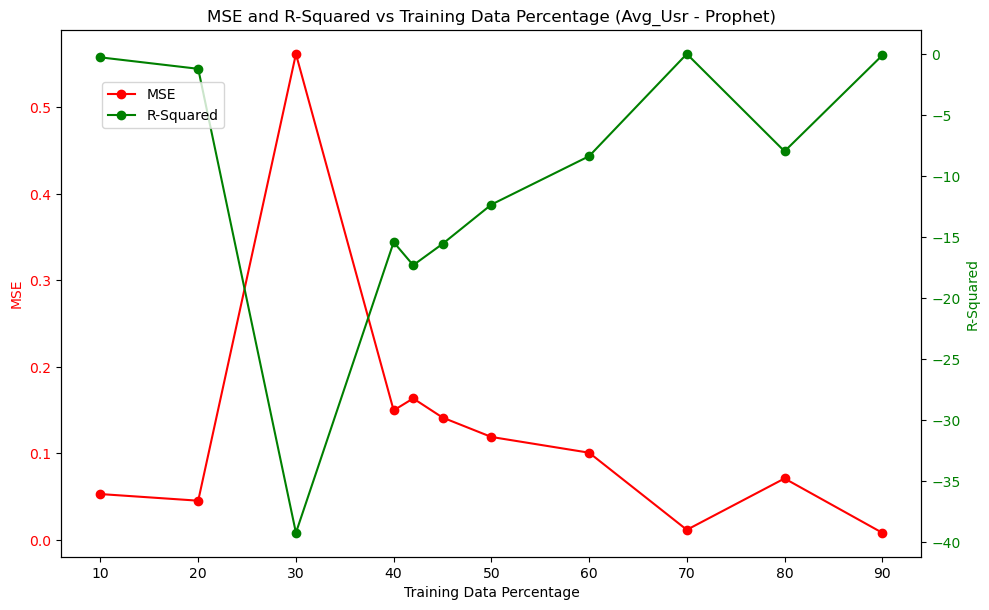

In [37]:
import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Prepare data
feature = 'Avg_Usr'

# Normalize the 'Avg_Usr' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Create a time series DataFrame for Prophet
prophet_df = pd.DataFrame({
    'ds': pd.date_range(start='2023-01-01', periods=len(scaled_data), freq='D'),
    'y': scaled_data.flatten()
})

# Parameters
train_percentages = [10, 20, 30, 40, 42, 45, 50, 60, 70, 80, 90]

# Initialize results list
results = []

# Train and evaluate Prophet for different train percentages
for percent in train_percentages:
    print(f"\nTraining with {percent}% of data:")

    # Split data into train and test
    train_size = int(len(prophet_df) * (percent / 100))
    train = prophet_df.iloc[:train_size]
    test = prophet_df.iloc[train_size:]

    # Train Prophet model
    try:
        model = Prophet()
        model.fit(train)

        # Create future dataframe
        future = model.make_future_dataframe(periods=len(test), freq='D')
        forecast = model.predict(future)

        # Extract predictions for the test set
        y_pred = forecast['yhat'][-len(test):].values
        y_true = test['y'].values

        # Calculate metrics
        mse = mean_squared_error(y_true, y_pred)
        r_squared = r2_score(y_true, y_pred)
    except Exception as e:
        print(f"Prophet failed for {percent}%: {e}")
        mse = np.nan
        r_squared = np.nan

    # Append results
    results.append({
        'Train (%)': percent,
        'MSE': mse,
        'R-Squared': r_squared
    })

    print(f"MSE: {mse:.8f}, R-squared: {r_squared:.8f}")

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Export results to Excel
results_df.to_excel('prophet_train_percentage_results.xlsx', index=False)

# Print tabular results
print("\nResults in Tabular Format:")
print(results_df)

# Plot MSE and R-Squared in a single figure
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot MSE
ax1.set_xlabel('Training Data Percentage')
ax1.set_ylabel('MSE', color='red')
ax1.plot(results_df['Train (%)'], results_df['MSE'], marker='o', color='red', label='MSE')
ax1.tick_params(axis='y', labelcolor='red')

# Add R-Squared on the same plot
ax2 = ax1.twinx()
ax2.set_ylabel('R-Squared', color='green')
ax2.plot(results_df['Train (%)'], results_df['R-Squared'], marker='o', color='green', label='R-Squared')
ax2.tick_params(axis='y', labelcolor='green')

# Title and legends
fig.tight_layout()
plt.title(f'MSE and R-Squared vs Training Data Percentage ({feature} - Prophet)')
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.show()


In [41]:

# Convert 'Date' column to datetime and prepare data
data['Date'] = pd.to_datetime(data['Date'], format='%d-%b-%y')
data = data[['Date', 'Avg_Usr']].rename(columns={'Date': 'ds', 'Avg_Usr': 'y'})

# Handle missing or duplicate dates
data = data.drop_duplicates(subset='ds').sort_values('ds').reset_index(drop=True)
data = data.dropna()  # Drop rows with missing values

# Ensure the time series has no missing dates (reindexing and filling missing values)
all_dates = pd.date_range(start=data['ds'].min(), end=data['ds'].max(), freq='D')
data = data.set_index('ds').reindex(all_dates).rename_axis('ds').reset_index()
data['y'] = data['y'].interpolate(method='linear')  # Fill missing 'y' values with linear interpolation

# Normalize the 'y' values
scaler = MinMaxScaler(feature_range=(0, 1))
data['y'] = scaler.fit_transform(data[['y']])

# Training percentages
train_percentages = [10, 20, 30, 40, 42, 45, 50, 60, 70, 80, 90]

# Initialize results list
results = []

# Train and evaluate Prophet model for each training percentage
for percent in train_percentages:
    print(f"\nTraining with {percent}% of data:")

    # Split into train and test sets
    train_size = int(len(data) * (percent / 100))
    train = data.iloc[:train_size]
    test = data.iloc[train_size:]

    # Train Prophet model
    try:
        model = Prophet()
        model.fit(train)

        # Predict for the test set
        future = model.make_future_dataframe(periods=len(test), freq='D')
        forecast = model.predict(future)

        # Extract predictions
        y_pred = forecast['yhat'][-len(test):].values
        y_true = test['y'].values

        # Calculate metrics
        mse = mean_squared_error(y_true, y_pred)
        r_squared = r2_score(y_true, y_pred)

    except Exception as e:
        print(f"Prophet failed for {percent}%: {e}")
        mse, r_squared = np.nan, np.nan

    # Append results
    results.append({
        'Train (%)': percent,
        'MSE': mse,
        'R-Squared': r_squared
    })

    print(f"MSE: {mse:.8f}, R-squared: {r_squared:.8f}")

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Save results to Excel
results_df.to_excel('prophet_results.xlsx', index=False)

# Print tabular results
print("\nResults in Tabular Format:")
print(results_df)

# Plot MSE and R-Squared
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot MSE
ax1.set_xlabel('Training Data Percentage')
ax1.set_ylabel('MSE', color='red')
ax1.plot(results_df['Train (%)'], results_df['MSE'], marker='o', color='red', label='MSE')
ax1.tick_params(axis='y', labelcolor='red')

# Add R-Squared on the same plot
ax2 = ax1.twinx()
ax2.set_ylabel('R-Squared', color='green')
ax2.plot(results_df['Train (%)'], results_df['R-Squared'], marker='o', color='green', label='R-Squared')
ax2.tick_params(axis='y', labelcolor='green')

# Title and legends
fig.tight_layout()
plt.title('MSE and R-Squared vs Training Data Percentage (Prophet)')
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.show()


KeyError: 'Date'

In [42]:
data

,ds,y
0,2022-09-01,0.036028
1,2022-09-02,0.016777
2,2022-09-03,0.021891
3,2022-09-04,0.052906
4,2022-09-05,0.021255
...,...,...
361,2023-08-28,0.698750
362,2023-08-29,0.812170
363,2023-08-30,0.808015
364,2023-08-31,0.745987


In [14]:
# List of the first 10 features based on dataset
selected_features = [
    'Avg_Usr', 'Avg_Usr_TP_UL', 'CSSR', 
    'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE', 
    'DL_QPSK_PROPORTION', 'DL_TRAFFIC_MB', 'Max_Usr', 
    'S1_SIG_SUCC', 'TOTAL_DOWNTIME', 'Traffic', 'UL_QPSK_PROPORTION', 'UL_TRAFFIC_MB'
]

# Target feature
target_feature = 'Avg_Usr_TP_DL'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + selected_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Function to create dataset matrix for GRU
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is the first column after scaling
    return np.array(X), np.array(Y)

# Function to train GRU model
def train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(GRU(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(GRU(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=14)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict

# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'rmsprop'
look_back = 3

# Dictionary to store R-squared for each feature or combination
r2_scores = []

# Step 1: Train GRU model with each feature individually
for feature in selected_features:
    # Prepare data with the current single feature and target feature
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

    # Create dataset for GRU
    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)

    # Reshape input data to 3D (samples, timesteps, features) for GRU input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

    # Train GRU model
    model, test_predict = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

    # Calculate R-squared
    r2 = r2_score(y_test, test_predict)
    r2_scores.append({"Features": feature, "R-squared": r2})

# Step 2: Train GRU model with all 10 features combined
selected_data = data[[target_feature] + selected_features]
data_scaled = scaler.fit_transform(selected_data)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Create dataset for GRU with all 10 features
X_train, y_train = create_dataset(train_data, look_back=look_back)
X_test, y_test = create_dataset(test_data, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Train GRU model
model, test_predict = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Calculate R-squared
r2 = r2_score(y_test, test_predict)
r2_scores.append({"Features": "All 10 Features Combined", "R-squared": r2})

# Convert results to DataFrame and sort by R-squared
r2_df = pd.DataFrame(r2_scores)
r2_df = r2_df.sort_values(by="R-squared", ascending=False).reset_index(drop=True)

# Display the table
print(r2_df)



3/3 [==============================] - 2s 4ms/step
                    Features  R-squared
0          DL_PACK_LOSS_RATE   0.661234
1                 DL_LATENCY   0.641938
2                    Traffic   0.544504
3              UL_TRAFFIC_MB   0.542926
4                       CSSR   0.499775
5             TOTAL_DOWNTIME   0.447095
6                    Max_Usr   0.436524
7                S1_SIG_SUCC   0.424727
8         DL_QPSK_PROPORTION   0.172310
9              DL_TRAFFIC_MB  -0.085727
10                   Avg_Usr  -0.088831
11        UL_QPSK_PROPORTION  -0.167241
12      DL_256QAM_PROPORTION  -0.671769
13             Avg_Usr_TP_UL  -0.904093
14  All 10 Features Combined  -5.243122


Epoch 1/50
9/9 [==============================] - 8s 131ms/step - loss: 0.0815 - val_loss: 0.0014
Epoch 2/50
9/9 [==============================] - 0s 14ms/step - loss: 0.0197 - val_loss: 0.0016
Epoch 3/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0066 - val_loss: 0.0102
Epoch 4/50
9/9 [==============================] - 0s 14ms/step - loss: 0.0055 - val_loss: 9.9942e-04
Epoch 5/50
9/9 [==============================] - 0s 14ms/step - loss: 0.0044 - val_loss: 7.9172e-04
Epoch 6/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0035 - val_loss: 0.0024
Epoch 7/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0034 - val_loss: 0.0011
Epoch 8/50
9/9 [==============================] - 0s 16ms/step - loss: 0.0032 - val_loss: 9.7812e-04
Epoch 9/50
9/9 [==============================] - 0s 15ms/step - loss: 0.0030 - val_loss: 0.0012
Epoch 10/50
9/9 [==============================] - 0s 15ms/step - loss: 0.0031 - val_loss: 9.4171e-04
Epoch 11/50


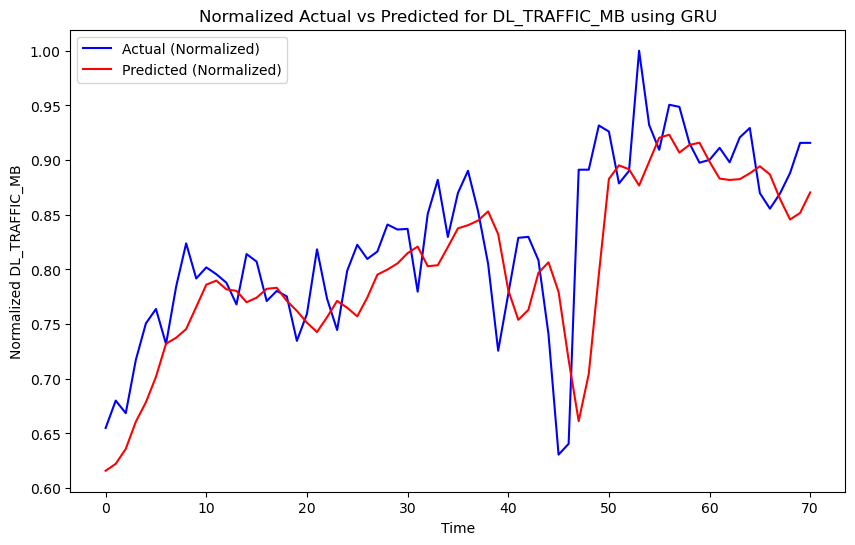

In [16]:
# Function to create dataset matrix for GRU
def create_dataset_gru(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'DL_TRAFFIC_MB'
feature = 'DL_TRAFFIC_MB'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for GRU (look_back=3)
look_back = 3
X_train, y_train = create_dataset_gru(train, look_back=look_back)
X_test, y_test = create_dataset_gru(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for GRU
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 1))
gru_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train)
test_predict_gru = gru_model.predict(X_test)

# Calculate MSE for the GRU model
gru_mse = mean_squared_error(y_test, test_predict_gru)
print(f'GRU Model MSE (Normalized): {gru_mse}')

# Calculate R-squared value
from sklearn.metrics import r2_score
gru_r2 = r2_score(y_test, test_predict_gru)
print(f'GRU Model R-squared (Normalized): {gru_r2}')

# Plot the GRU model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using GRU')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [17]:

# List of the first 10 features based on dataset
selected_features = [
    'Avg_Usr', 'Avg_Usr_TP_UL', 'CSSR', 
    'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE', 
    'DL_QPSK_PROPORTION', 'Avg_Usr_TP_DL', 'Max_Usr', 
    'S1_SIG_SUCC', 'TOTAL_DOWNTIME', 'Traffic', 'UL_QPSK_PROPORTION', 'UL_TRAFFIC_MB'
]

# Target feature
target_feature = 'DL_TRAFFIC_MB'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + selected_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Function to create dataset matrix for GRU
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is the first column after scaling
    return np.array(X), np.array(Y)

# Function to train GRU model
def train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(GRU(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(GRU(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=14)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict

# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'rmsprop'
look_back = 3

# Dictionary to store R-squared for each feature or combination
r2_scores = []

# Step 1: Train GRU model with each feature individually
for feature in selected_features:
    # Prepare data with the current single feature and target feature
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

    # Create dataset for GRU
    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)

    # Reshape input data to 3D (samples, timesteps, features) for GRU input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

    # Train GRU model
    model, test_predict = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

    # Calculate R-squared
    r2 = r2_score(y_test, test_predict)
    r2_scores.append({"Features": feature, "R-squared": r2})

# Step 2: Train GRU model with all 10 features combined
selected_data = data[[target_feature] + selected_features]
data_scaled = scaler.fit_transform(selected_data)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Create dataset for GRU with all 10 features
X_train, y_train = create_dataset(train_data, look_back=look_back)
X_test, y_test = create_dataset(test_data, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Train GRU model
model, test_predict = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Calculate R-squared
r2 = r2_score(y_test, test_predict)
r2_scores.append({"Features": "All 10 Features Combined", "R-squared": r2})

# Convert results to DataFrame and sort by R-squared
r2_df = pd.DataFrame(r2_scores)
r2_df = r2_df.sort_values(by="R-squared", ascending=False).reset_index(drop=True)

# Display the table
print(r2_df)


3/3 [==============================] - 1s 3ms/step
                    Features  R-squared
0                       CSSR   0.374453
1         UL_QPSK_PROPORTION   0.339833
2                    Max_Usr  -0.034642
3              Avg_Usr_TP_DL  -0.149233
4                    Traffic  -0.180570
5                 DL_LATENCY  -0.971129
6         DL_QPSK_PROPORTION  -1.124703
7             TOTAL_DOWNTIME  -1.461704
8   All 10 Features Combined  -3.239888
9              Avg_Usr_TP_UL  -3.296178
10             UL_TRAFFIC_MB  -3.451676
11                   Avg_Usr  -5.518674
12               S1_SIG_SUCC  -5.695879
13      DL_256QAM_PROPORTION  -8.367149
14         DL_PACK_LOSS_RATE -10.413264


In [26]:

# List of the first 10 features based on dataset
selected_features = [
    'Avg_Usr', 'Avg_Usr_TP_UL', 'CSSR', 
    'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE', 
    'DL_QPSK_PROPORTION', 'Avg_Usr_TP_DL', 'Max_Usr', 
    'S1_SIG_SUCC', 'TOTAL_DOWNTIME', 'Traffic', 'UL_QPSK_PROPORTION', 'UL_TRAFFIC_MB'
]

# Target feature
target_feature = 'DL_TRAFFIC_MB'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + selected_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Function to create dataset matrix for GRU
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is the first column after scaling
    return np.array(X), np.array(Y)

# Function to train GRU model
def train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(GRU(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(GRU(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=14)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict

# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'rmsprop'
look_back = 3

# Dictionary to store R-squared for each feature or combination
r2_scores = []

# Step 1: Train GRU model with each feature individually
for feature in selected_features:
    # Prepare data with the current single feature and target feature
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

    # Create dataset for GRU
    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)

    # Reshape input data to 3D (samples, timesteps, features) for GRU input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

    # Train GRU model
    model, test_predict = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

    # Calculate R-squared
    r2 = r2_score(y_test, test_predict)
    r2_scores.append({"Features": feature, "R-squared": r2})

# Step 2: Train GRU model with all 10 features combined
selected_data = data[[target_feature] + selected_features]
data_scaled = scaler.fit_transform(selected_data)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Create dataset for GRU with all 10 features
X_train, y_train = create_dataset(train_data, look_back=look_back)
X_test, y_test = create_dataset(test_data, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Train GRU model
model, test_predict = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Calculate R-squared
r2 = r2_score(y_test, test_predict)
r2_scores.append({"Features": "All 10 Features Combined", "R-squared": r2})

# Convert results to DataFrame and sort by R-squared
r2_df = pd.DataFrame(r2_scores)
r2_df = r2_df.sort_values(by="R-squared", ascending=False).reset_index(drop=True)

# Display the table
print(r2_df)


3/3 [==============================] - 1s 2ms/step
                    Features  R-squared
0                S1_SIG_SUCC   0.520432
1         UL_QPSK_PROPORTION   0.366753
2                 DL_LATENCY   0.222727
3             TOTAL_DOWNTIME   0.065071
4                       CSSR  -0.054228
5                    Max_Usr  -0.234366
6         DL_QPSK_PROPORTION  -0.403069
7          DL_PACK_LOSS_RATE  -0.689132
8              Avg_Usr_TP_DL  -1.113389
9                    Traffic  -3.755092
10                   Avg_Usr  -4.742798
11  All 10 Features Combined  -6.277814
12             UL_TRAFFIC_MB  -8.815876
13      DL_256QAM_PROPORTION  -9.002471
14             Avg_Usr_TP_UL -10.585940


In [28]:
# Step 1: Feature Importance and Selection
from sklearn.inspection import permutation_importance

# Compute permutation importance for initial feature set
X = data[selected_features]
y = data[target_feature]
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1))

train_size = int(len(X_scaled) * 0.8)
# Reshape the data for GRU model
X_train_fs = np.reshape(X_train_fs, (X_train_fs.shape[0], 1, X_train_fs.shape[1]))
X_test_fs = np.reshape(X_test_fs, (X_test_fs.shape[0], 1, X_test_fs.shape[1]))

# Train the model with reshaped data
model_fs, _ = train_gru_model(X_train_fs, y_train_fs, X_test_fs, y_test_fs, units, dropout_rate, batch_size, epochs, optimizer)

# Compute feature importance
perm_importance = permutation_importance(model_fs, X_test_fs, y_test_fs, scoring='neg_mean_squared_error')
feature_importances = perm_importance.importances_mean

# Update selected features based on importance threshold
important_features = [selected_features[i] for i in range(len(selected_features)) if feature_importances[i] > 0.01]
print("Important Features:", important_features)

# Step 2: Feature Engineering
# Add interaction terms or polynomial features if applicable
X_engineered = X.copy()
X_engineered['DL_LATENCY_TRAFFIC'] = X['DL_LATENCY'] * X['Traffic']  # Example interaction term
X_engineered_scaled = scaler.fit_transform(X_engineered)

train_size = int(len(X_engineered_scaled) * 0.8)
X_train_fe, X_test_fe = X_engineered_scaled[:train_size], X_engineered_scaled[train_size:]

# Train model with engineered features
model_fe, test_predict_fe = train_gru_model(X_train_fe, y_train_fs, X_test_fe, y_test_fs, units, dropout_rate, batch_size, epochs, optimizer)

test_r2_fe = r2_score(y_test_fs, test_predict_fe)
print(f"R-squared value after feature engineering: {test_r2_fe}")

# Step 3: Regularization
# Update GRU model with L2 regularization
from tensorflow.keras.regularizers import l2

def train_gru_with_regularization(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer, reg_lambda):
    model = Sequential()
    model.add(GRU(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2]), kernel_regularizer=l2(reg_lambda)))
    model.add(Dropout(dropout_rate))
    model.add(GRU(units // 2, return_sequences=False, kernel_regularizer=l2(reg_lambda)))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=14)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict

reg_lambda = 0.01
model_reg, test_predict_reg = train_gru_with_regularization(X_train_fe, y_train_fs, X_test_fe, y_test_fs, units, dropout_rate, batch_size, epochs, optimizer, reg_lambda)

test_r2_reg = r2_score(y_test_fs, test_predict_reg)
print(f"R-squared value after regularization: {test_r2_reg}")

# Step 4: Hyperparameter Tuning
# Perform grid search for optimal hyperparameters
from sklearn.model_selection import ParameterGrid

param_grid = {
    'units': [50, 100],
    'dropout_rate': [0.2, 0.4],
    'batch_size': [32, 64],
    'epochs': [50, 100]
}

best_r2 = float('-inf')
best_params = None

for params in ParameterGrid(param_grid):
    model_ht, test_predict_ht = train_gru_model(X_train_fe, y_train_fs, X_test_fe, y_test_fs, 
                                                params['units'], params['dropout_rate'], 
                                                params['batch_size'], params['epochs'], optimizer)
    test_r2_ht = r2_score(y_test_fs, test_predict_ht)
    if test_r2_ht > best_r2:
        best_r2 = test_r2_ht
        best_params = params

print(f"Best hyperparameters: {best_params}, R-squared: {best_r2}")

# Step 5: Data Augmentation
# Synthetic Data Generation for Augmentation
augmented_data = np.tile(X_train_fe, (2, 1))  # Example: Duplicate training data for augmentation
augmented_y = np.tile(y_train_fs, (2, 1))

model_aug, test_predict_aug = train_gru_model(augmented_data, augmented_y, X_test_fe, y_test_fs, units, dropout_rate, batch_size, epochs, optimizer)

test_r2_aug = r2_score(y_test_fs, test_predict_aug)
print(f"R-squared value after data augmentation: {test_r2_aug}")

# Step 6: Model Architecture
# Experiment with LSTM architecture
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(tf.keras.layers.LSTM(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(tf.keras.layers.LSTM(50, return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

lstm_model = build_lstm_model((X_train_fe.shape[1], X_train_fe.shape[2]))
lstm_model.fit(X_train_fe, y_train_fs, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

lstm_test_predict = lstm_model.predict(X_test_fe)
lstm_r2 = r2_score(y_test_fs, lstm_test_predict)
print(f"R-squared value using LSTM: {lstm_r2}")

# Step 3: Forecasting using the target feature alone
# Prepare data with only the target feature
forecast_data = data[[target_feature]]
data_scaled = scaler.fit_transform(forecast_data)

# Create dataset for GRU with the target feature only
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

X_train, y_train = create_dataset(train_data, look_back=look_back)
X_test, y_test = create_dataset(test_data, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))  # Only one feature
dropout_rate = 0.4
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Train GRU model
model, test_predict = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Generate future forecasting (e.g., next 10 steps)
def forecast_future(model, data, look_back, steps):
    forecast = []
    input_seq = data[-look_back:]  # Start with the last sequence in the dataset

    for _ in range(steps):
        input_seq_reshaped = np.reshape(input_seq, (1, look_back, 1))  # Reshape for model input
        next_step = model.predict(input_seq_reshaped, verbose=0)[0, 0]  # Predict next step
        forecast.append(next_step)

        # Update the input sequence with the predicted value
        input_seq = np.append(input_seq[1:], [[next_step]], axis=0)

    return forecast

# Generate forecast for the next 10 time steps
forecast_steps = 10
forecast = forecast_future(model, data_scaled[:, 0], look_back, forecast_steps)

# Inverse transform forecasted values to original scale
forecast_original_scale = scaler.inverse_transform(np.concatenate([data_scaled, np.array(forecast).reshape(-1, 1)], axis=0))
forecast_values = forecast_original_scale[-forecast_steps:, 0]

# Display forecasted values
print("Forecasted Values for Next 10 Steps:")
print(forecast_values)

# Calculate R-squared value for test predictions
from sklearn.metrics import r2_score

test_r2_score = r2_score(y_test, test_predict)
print(f"R-squared value for test predictions: {test_r2_score}")


3/3 [==============================] - 1s 3ms/step


ValueError: Found array with dim 3. None expected <= 2.

In [8]:

# List of the first 10 features based on dataset
selected_features = [
    'Avg_Usr', 'Avg_Usr_TP_UL', 'CSSR', 
    'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE', 
    'DL_QPSK_PROPORTION', 'Avg_Usr_TP_DL', 'Max_Usr', 
    'S1_SIG_SUCC', 'TOTAL_DOWNTIME', 'Traffic', 'UL_QPSK_PROPORTION', 'UL_TRAFFIC_MB'
]

# Target feature
target_feature = 'DL_TRAFFIC_MB'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + selected_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Function to create dataset matrix for GRU
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is the first column after scaling
    return np.array(X), np.array(Y)

# Function to train GRU model
def train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(GRU(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(GRU(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=14)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict

# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'rmsprop'
look_back = 3

# Dictionary to store R-squared for each feature or combination
r2_scores = []

# Step 1: Train GRU model with each feature individually
for feature in selected_features:
    # Prepare data with the current single feature and target feature
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

    # Create dataset for GRU
    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)

    # Reshape input data to 3D (samples, timesteps, features) for GRU input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

    # Train GRU model
    model, test_predict = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

    # Calculate R-squared
    r2 = r2_score(y_test, test_predict)
    r2_scores.append({"Features": feature, "R-squared": r2})

# Step 2: Train GRU model with all 10 features combined
selected_data = data[[target_feature] + selected_features]
data_scaled = scaler.fit_transform(selected_data)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Create dataset for GRU with all 10 features
X_train, y_train = create_dataset(train_data, look_back=look_back)
X_test, y_test = create_dataset(test_data, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Train GRU model
model, test_predict = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Calculate R-squared
r2 = r2_score(y_test, test_predict)
r2_scores.append({"Features": "All 10 Features Combined", "R-squared": r2})

# Convert results to DataFrame and sort by R-squared
r2_df = pd.DataFrame(r2_scores)
r2_df = r2_df.sort_values(by="R-squared", ascending=False).reset_index(drop=True)

# Display the table
print(r2_df)


3/3 [==============================] - 1s 3ms/step
                    Features  R-squared
0                 DL_LATENCY   0.281635
1         UL_QPSK_PROPORTION   0.260485
2                S1_SIG_SUCC   0.033483
3              Avg_Usr_TP_DL  -0.170539
4                    Max_Usr  -0.480451
5             TOTAL_DOWNTIME  -0.632182
6                       CSSR  -0.791631
7                    Avg_Usr  -1.755402
8         DL_QPSK_PROPORTION  -2.248764
9                    Traffic  -2.314284
10         DL_PACK_LOSS_RATE  -3.508975
11             Avg_Usr_TP_UL  -4.949875
12      DL_256QAM_PROPORTION  -7.692516
13             UL_TRAFFIC_MB  -8.374350
14  All 10 Features Combined  -9.247340


In [6]:
# List of potential features to use for multivariate analysis
all_features = ['Avg_Usr_TP_DL', 'Avg_Usr_TP_UL', 'CSSR', 'DL_256QAM_PROPORTION',
                'DL_LATENCY', 'DL_PACK_LOSS_RATE', 'DL_QPSK_PROPORTION', 'DL_TRAFFIC_MB', 
                'Max_Usr', 'S1_SIG_SUCC', 'TOTAL_DOWNTIME', 'Traffic', 'UL_QPSK_PROPORTION', 
                'UL_TRAFFIC_MB']

In [7]:
# Target feature
target_feature = 'Avg_Usr'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + all_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]


In [8]:
# Function to create dataset matrix for GRU
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is Avg_Usr (first column after scaling)
    return np.array(X), np.array(Y)

# Function to train GRU model
def train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(GRU(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(GRU(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=10)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history

In [9]:
# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'rmsprop'
look_back = 3

# Dictionary to store MSE for each feature combination
mse_scores = {}

In [16]:
# Iterate over different combinations of features
for i in range(1, len(all_features) + 1):
    for feature_comb in combinations(all_features, i):
        # Prepare data with selected features
        selected_features = [target_feature] + list(feature_comb)
        feature_indices = [data.columns.get_loc(f) for f in selected_features]
        
        train_data_selected = train_data[:, feature_indices]
        test_data_selected = test_data[:, feature_indices]
        
        # Create dataset for GRU
        X_train, y_train = create_dataset(train_data_selected, look_back=look_back)
        X_test, y_test = create_dataset(test_data_selected, look_back=look_back)
        
        # Reshape input data to 3D (samples, timesteps, features) for GRU input
        X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], len(feature_comb) + 1))
        X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], len(feature_comb) + 1))
        
        # Train GRU model
        model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)
        
        # Calculate MSE
        mse = mean_squared_error(y_test, test_predict)
        mse_scores[feature_comb] = mse
        print(f'Features: {feature_comb}, MSE: {mse}')

3/3 [==============================] - 1s 3ms/step
Features: ('Avg_Usr_TP_DL',), MSE: 0.006574869124757399
3/3 [==============================] - 1s 3ms/step
Features: ('Avg_Usr_TP_UL',), MSE: 0.014255380358740083
3/3 [==============================] - 1s 3ms/step
Features: ('CSSR',), MSE: 0.012125692598425069
3/3 [==============================] - 1s 2ms/step
Features: ('DL_256QAM_PROPORTION',), MSE: 0.021859409620801195
3/3 [==============================] - 1s 2ms/step
Features: ('DL_LATENCY',), MSE: 0.005074480306087444
3/3 [==============================] - 1s 3ms/step
Features: ('DL_PACK_LOSS_RATE',), MSE: 0.0036486142351686225
3/3 [==============================] - 1s 2ms/step
Features: ('DL_QPSK_PROPORTION',), MSE: 0.00646577484355463
3/3 [==============================] - 1s 5ms/step
Features: ('DL_TRAFFIC_MB',), MSE: 0.008349676090636629
3/3 [==============================] - 1s 3ms/step
Features: ('Max_Usr',), MSE: 0.0061833447317497315
3/3 [==============================] -

IndexError: index 15 is out of bounds for axis 1 with size 15

In [12]:
data.columns

Index(['Date', 'Avg_Usr', 'Avg_Usr_TP_DL', 'Avg_Usr_TP_UL', 'CSSR',
       'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE',
       'DL_QPSK_PROPORTION', 'DL_TRAFFIC_MB', 'Max_Usr', 'S1_SIG_SUCC',
       'TOTAL_DOWNTIME', 'Traffic', 'UL_QPSK_PROPORTION', 'UL_TRAFFIC_MB'],
      dtype='object')

In [3]:
# List of the first 10 features based on dataset
selected_features = [
    'Avg_Usr_TP_DL', 'Avg_Usr_TP_UL', 'CSSR', 
    'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE', 
    'DL_QPSK_PROPORTION', 'DL_TRAFFIC_MB', 'Max_Usr', 
    'S1_SIG_SUCC'
]

# Target feature
target_feature = 'Avg_Usr'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + selected_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Function to create dataset matrix for GRU
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is the first column after scaling
    return np.array(X), np.array(Y)

# Function to train GRU model
def train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(GRU(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(GRU(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=10)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history

# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'rmsprop'
look_back = 3

# Dictionary to store MSE for each feature or combination
mse_scores = []

# Step 1: Train GRU model with each feature individually
for feature in selected_features:
    # Prepare data with the current single feature and target feature
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]
    
    # Create dataset for GRU
    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)
    
    # Reshape input data to 3D (samples, timesteps, features) for GRU input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))
    
    # Train GRU model
    model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)
    
    # Calculate MSE
    mse = mean_squared_error(y_test, test_predict)
    mse_scores.append({"Features": feature, "MSE": mse})

# Step 2: Train GRU model with all 10 features combined
selected_data = data[[target_feature] + selected_features]
data_scaled = scaler.fit_transform(selected_data)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Create dataset for GRU with all 10 features
X_train, y_train = create_dataset(train_data, look_back=look_back)
X_test, y_test = create_dataset(test_data, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Train GRU model
model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Calculate MSE
mse = mean_squared_error(y_test, test_predict)
mse_scores.append({"Features": "All 10 Features Combined", "MSE": mse})

# Convert results to DataFrame and sort by MSE
mse_df = pd.DataFrame(mse_scores)
mse_df = mse_df.sort_values(by="MSE").reset_index(drop=True)

# Display the table
print(mse_df)

3/3 [==============================] - 3s 8ms/step
                    Features       MSE
0                 DL_LATENCY  0.005487
1              Avg_Usr_TP_UL  0.006116
2       DL_256QAM_PROPORTION  0.006225
3              Avg_Usr_TP_DL  0.006400
4              DL_TRAFFIC_MB  0.007529
5                       CSSR  0.010082
6          DL_PACK_LOSS_RATE  0.011493
7         DL_QPSK_PROPORTION  0.014507
8                S1_SIG_SUCC  0.021112
9                    Max_Usr  0.025195
10  All 10 Features Combined  0.093235


In [5]:
from sklearn.metrics import r2_score
# Step 1: Train GRU model with each feature individually
for feature in selected_features:
    # Prepare data with the current single feature and target feature
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]
    
    # Create dataset for GRU
    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)
    
    # Reshape input data to 3D (samples, timesteps, features) for GRU input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))
    
    # Train GRU model
    model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)
    
    # Calculate MSE and R-squared
    mse = mean_squared_error(y_test, test_predict)
    r_squared = r2_score(y_test, test_predict)
    mse_scores.append({"Features": feature, "MSE": mse, "R-squared": r_squared})

# Step 2: Train GRU model with all 10 features combined
selected_data = data[[target_feature] + selected_features]
data_scaled = scaler.fit_transform(selected_data)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Create dataset for GRU with all 10 features
X_train, y_train = create_dataset(train_data, look_back=look_back)
X_test, y_test = create_dataset(test_data, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Train GRU model
model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Calculate MSE and R-squared
mse = mean_squared_error(y_test, test_predict)
r_squared = r2_score(y_test, test_predict)
mse_scores.append({"Features": "All 10 Features Combined", "MSE": mse, "R-squared": r_squared})

# Convert results to DataFrame and sort by MSE
mse_df = pd.DataFrame(mse_scores)
mse_df = mse_df.sort_values(by="MSE").reset_index(drop=True)

# Display the table
print(mse_df)

3/3 [==============================] - 2s 3ms/step
                    Features       MSE  R-squared
0                 DL_LATENCY  0.005487        NaN
1              Avg_Usr_TP_UL  0.006116        NaN
2       DL_256QAM_PROPORTION  0.006225        NaN
3              Avg_Usr_TP_DL  0.006400        NaN
4       DL_256QAM_PROPORTION  0.006657   0.103991
5              DL_TRAFFIC_MB  0.006712   0.096526
6              Avg_Usr_TP_UL  0.007286   0.019350
7              DL_TRAFFIC_MB  0.007529        NaN
8   All 10 Features Combined  0.009588  -0.290526
9                       CSSR  0.010082        NaN
10         DL_PACK_LOSS_RATE  0.011493        NaN
11                   Max_Usr  0.012275  -0.652255
12               S1_SIG_SUCC  0.012751  -0.716306
13                      CSSR  0.013486  -0.815237
14             Avg_Usr_TP_DL  0.013650  -0.837286
15        DL_QPSK_PROPORTION  0.014507        NaN
16                DL_LATENCY  0.015386  -1.070929
17        DL_QPSK_PROPORTION  0.016206  -1.181365

In [14]:
# List of the first 10 features based on dataset
selected_features = [
    'Avg_Usr_TP_DL', 'Avg_Usr_TP_UL', 'CSSR', 
    'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE', 
    'DL_QPSK_PROPORTION', 'DL_TRAFFIC_MB', 'Max_Usr', 
    'S1_SIG_SUCC', 'TOTAL_DOWNTIME', 'Traffic', 'UL_QPSK_PROPORTION', 'UL_TRAFFIC_MB'
]

# Target feature
target_feature = 'Avg_Usr'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + selected_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Function to create dataset matrix for GRU
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is the first column after scaling
    return np.array(X), np.array(Y)

# Function to train GRU model
def train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(GRU(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(GRU(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=14)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history

# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'rmsprop'
look_back = 3

# Dictionary to store MSE for each feature or combination
mse_scores = []

# Step 1: Train GRU model with each feature individually
for feature in selected_features:
    # Prepare data with the current single feature and target feature
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]
    
    # Create dataset for GRU
    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)
    
    # Reshape input data to 3D (samples, timesteps, features) for GRU input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))
    
    # Train GRU model
    model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)
    
    # Calculate MSE
    mse = mean_squared_error(y_test, test_predict)
    mse_scores.append({"Features": feature, "MSE": mse})

# Step 2: Train GRU model with all 10 features combined
selected_data = data[[target_feature] + selected_features]
data_scaled = scaler.fit_transform(selected_data)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Create dataset for GRU with all 10 features
X_train, y_train = create_dataset(train_data, look_back=look_back)
X_test, y_test = create_dataset(test_data, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Train GRU model
model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Calculate MSE
mse = mean_squared_error(y_test, test_predict)
mse_scores.append({"Features": "All 10 Features Combined", "MSE": mse})

# Convert results to DataFrame and sort by MSE
mse_df = pd.DataFrame(mse_scores)
mse_df = mse_df.sort_values(by="MSE").reset_index(drop=True)

# Display the table
print(mse_df)

3/3 [==============================] - 1s 4ms/step
                    Features       MSE
0         UL_QPSK_PROPORTION  0.005294
1                    Traffic  0.005506
2              UL_TRAFFIC_MB  0.005603
3              Avg_Usr_TP_DL  0.005625
4         DL_QPSK_PROPORTION  0.005734
5              DL_TRAFFIC_MB  0.006208
6             TOTAL_DOWNTIME  0.006584
7                    Max_Usr  0.006990
8                 DL_LATENCY  0.010487
9                       CSSR  0.010846
10             Avg_Usr_TP_UL  0.011866
11      DL_256QAM_PROPORTION  0.012016
12         DL_PACK_LOSS_RATE  0.017575
13               S1_SIG_SUCC  0.025639
14  All 10 Features Combined  0.026557


In [15]:
# List of the first 10 features based on dataset
selected_features = [
    'Avg_Usr', 'Avg_Usr_TP_UL', 'CSSR', 
    'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE', 
    'DL_QPSK_PROPORTION', 'DL_TRAFFIC_MB', 'Max_Usr', 
    'S1_SIG_SUCC', 'TOTAL_DOWNTIME', 'Traffic', 'UL_QPSK_PROPORTION', 'UL_TRAFFIC_MB'
]

# Target feature
target_feature = 'Avg_Usr_TP_DL'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + selected_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Function to create dataset matrix for GRU
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is the first column after scaling
    return np.array(X), np.array(Y)

# Function to train GRU model
def train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(GRU(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(GRU(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=14)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history

# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'rmsprop'
look_back = 3

# Dictionary to store MSE for each feature or combination
mse_scores = []

# Step 1: Train GRU model with each feature individually
for feature in selected_features:
    # Prepare data with the current single feature and target feature
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]
    
    # Create dataset for GRU
    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)
    
    # Reshape input data to 3D (samples, timesteps, features) for GRU input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))
    
    # Train GRU model
    model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)
    
    # Calculate MSE
    mse = mean_squared_error(y_test, test_predict)
    mse_scores.append({"Features": feature, "MSE": mse})

# Step 2: Train GRU model with all 10 features combined
selected_data = data[[target_feature] + selected_features]
data_scaled = scaler.fit_transform(selected_data)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Create dataset for GRU with all 10 features
X_train, y_train = create_dataset(train_data, look_back=look_back)
X_test, y_test = create_dataset(test_data, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Train GRU model
model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Calculate MSE
mse = mean_squared_error(y_test, test_predict)
mse_scores.append({"Features": "All 10 Features Combined", "MSE": mse})

# Convert results to DataFrame and sort by MSE
mse_df = pd.DataFrame(mse_scores)
mse_df = mse_df.sort_values(by="MSE").reset_index(drop=True)

# Display the table
print(mse_df)

3/3 [==============================] - 1s 2ms/step
                    Features       MSE
0                       CSSR  0.004213
1       DL_256QAM_PROPORTION  0.004233
2                    Traffic  0.005095
3          DL_PACK_LOSS_RATE  0.005615
4                    Avg_Usr  0.005652
5         UL_QPSK_PROPORTION  0.006775
6              Avg_Usr_TP_UL  0.008636
7                S1_SIG_SUCC  0.009100
8             TOTAL_DOWNTIME  0.010378
9              DL_TRAFFIC_MB  0.013540
10        DL_QPSK_PROPORTION  0.015366
11                   Max_Usr  0.018489
12             UL_TRAFFIC_MB  0.024419
13                DL_LATENCY  0.026149
14  All 10 Features Combined  0.089882


In [22]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Tdata.csv')

# List of the first 10 features based on dataset
selected_features = [
    'Avg_Usr', 'Avg_Usr_TP_UL', 'CSSR', 
    'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE', 
    'DL_QPSK_PROPORTION', 'Avg_Usr_TP_DL', 'Max_Usr', 
    'S1_SIG_SUCC', 'TOTAL_DOWNTIME', 'Traffic', 'UL_QPSK_PROPORTION', 'UL_TRAFFIC_MB'
]

# Target feature
target_feature = 'DL_TRAFFIC_MB'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + selected_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Function to create dataset matrix for GRU
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is the first column after scaling
    return np.array(X), np.array(Y)

# Function to train GRU model
def train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(GRU(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(GRU(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=14)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history

# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'rmsprop'
look_back = 3

# Dictionary to store MSE for each feature or combination
mse_scores = []

# Step 1: Train GRU model with each feature individually
for feature in selected_features:
    # Prepare data with the current single feature and target feature
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]
    
    # Create dataset for GRU
    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)
    
    # Reshape input data to 3D (samples, timesteps, features) for GRU input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))
    
    # Train GRU model
    model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)
    
    # Calculate MSE
    mse = mean_squared_error(y_test, test_predict)
    mse_scores.append({"Features": feature, "MSE": mse})

# Step 2: Train GRU model with all 10 features combined
selected_data = data[[target_feature] + selected_features]
data_scaled = scaler.fit_transform(selected_data)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Create dataset for GRU with all 10 features
X_train, y_train = create_dataset(train_data, look_back=look_back)
X_test, y_test = create_dataset(test_data, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Train GRU model
model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Calculate MSE
mse = mean_squared_error(y_test, test_predict)
mse_scores.append({"Features": "All 10 Features Combined", "MSE": mse})

# Convert results to DataFrame and sort by MSE
mse_df = pd.DataFrame(mse_scores)
mse_df = mse_df.sort_values(by="MSE").reset_index(drop=True)

# Display the table
print(mse_df)

3/3 [==============================] - 2s 3ms/step
                    Features       MSE
0                 DL_LATENCY  0.002979
1          DL_PACK_LOSS_RATE  0.004257
2                    Traffic  0.004750
3                       CSSR  0.008330
4                S1_SIG_SUCC  0.008849
5         UL_QPSK_PROPORTION  0.010155
6                    Max_Usr  0.011293
7              Avg_Usr_TP_DL  0.011770
8              Avg_Usr_TP_UL  0.020315
9             TOTAL_DOWNTIME  0.020857
10                   Avg_Usr  0.026852
11      DL_256QAM_PROPORTION  0.034961
12        DL_QPSK_PROPORTION  0.041642
13             UL_TRAFFIC_MB  0.058369
14  All 10 Features Combined  0.078856


In [18]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Area3.csv')

In [21]:
data.columns

Index(['Date', 'AVG_NO_USER', 'AVG_USR_THRPUT_DL', 'DL_TRAFFIC_MB'], dtype='object')

In [1]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Tdata.csv')

# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'Avg_Usr'
feature = 'Avg_Usr'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# SVM Model Prediction
look_back = 3
X_train_svm, y_train_svm = create_dataset_svm(train, look_back=look_back)
X_test_svm, y_test_svm = create_dataset_svm(test, look_back=look_back)

svm_model = SVR(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict with SVM
train_predict_svm = svm_model.predict(X_train_svm)
test_predict_svm = svm_model.predict(X_test_svm)

# Prepare the data for LSTM/GRU hybrid
def create_dataset_hybrid(svm_predictions, original_data, look_back=1):
    X, Y = [], []
    for i in range(len(svm_predictions) - look_back):
        # Combine original time series and SVM predictions as features
        feature_set = np.hstack((original_data[i:(i + look_back)], svm_predictions[i:(i + look_back)].reshape(-1, 1)))
        X.append(feature_set)
        Y.append(original_data[i + look_back, 0])
    return np.array(X), np.array(Y)

# Create dataset for LSTM using SVM predictions
X_train_lstm, y_train_lstm = create_dataset_hybrid(train_predict_svm, train, look_back=look_back)
X_test_lstm, y_test_lstm = create_dataset_hybrid(test_predict_svm, test, look_back=look_back)

# Reshape input data for LSTM (samples, timesteps, features)
X_train_lstm = np.reshape(X_train_lstm, (X_train_lstm.shape[0], X_train_lstm.shape[1], 2))
X_test_lstm = np.reshape(X_test_lstm, (X_test_lstm.shape[0], X_test_lstm.shape[1], 2))

# Function to build and train LSTM and GRU models
def build_lstm_gru_model(input_shape, lstm_units, gru_units, dropout_rate):
    model = Sequential()
    model.add(LSTM(lstm_units, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(dropout_rate))
    model.add(GRU(gru_units, return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Loop through different hyperparameter configurations
best_mse = float('inf')
best_params = {}
best_model = None

for lstm_units in [50, 100]:
    for gru_units in [50, 100]:
        for dropout_rate in [0.2, 0.3]:
            for batch_size in [32, 64]:
                for epochs in [50, 100]:
                    print(f'Training with LSTM units={lstm_units}, GRU units={gru_units}, dropout_rate={dropout_rate}, batch_size={batch_size}, epochs={epochs}')
                    model = build_lstm_gru_model((look_back, 2), lstm_units, gru_units, dropout_rate)
                    model.fit(X_train_lstm, y_train_lstm, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=1)
                    
                    # Predict
                    test_predict = model.predict(X_test_lstm)
                    
                    # Calculate MSE
                    mse = mean_squared_error(y_test_lstm, test_predict)
                    print(f'MSE: {mse}')
                    
                    if mse < best_mse:
                        best_mse = mse
                        best_params = {'lstm_units': lstm_units, 'gru_units': gru_units, 'dropout_rate': dropout_rate, 'batch_size': batch_size, 'epochs': epochs}
                        best_model = model

print(f'Best MSE: {best_mse} with params: {best_params}')

# Predict with the best model
best_test_predict = best_model.predict(X_test_lstm)

# Invert predictions and actual values back to original scale
#best_test_predict = scaler.inverse_transform(best_test_predict)
#y_test_lstm = scaler.inverse_transform([y_test_lstm])

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(y_test_lstm[0], label='Actual', color='blue')
plt.plot(best_test_predict, label='Predicted', color='red')
plt.title(f'Actual vs Predicted for Avg_Usr using Stacked SVM-LSTM-GRU Model')
plt.xlabel('Time')
plt.ylabel('Avg_Usr')
plt.legend()
plt.show()

NameError: name 'pd' is not defined

Training SVM with kernel=linear, C=0.1, gamma=scale
MSE for SVM: 0.007014629818826911
Training SVM with kernel=linear, C=0.1, gamma=auto
MSE for SVM: 0.007014629818826911
Training SVM with kernel=linear, C=1, gamma=scale
MSE for SVM: 0.005632253323588096
Training SVM with kernel=linear, C=1, gamma=auto
MSE for SVM: 0.005632253323588096
Training SVM with kernel=linear, C=10, gamma=scale
MSE for SVM: 0.005565494518045634
Training SVM with kernel=linear, C=10, gamma=auto
MSE for SVM: 0.005565494518045634
Training SVM with kernel=rbf, C=0.1, gamma=scale
MSE for SVM: 0.009402962084865782
Training SVM with kernel=rbf, C=0.1, gamma=auto
MSE for SVM: 0.011126600625618318
Training SVM with kernel=rbf, C=1, gamma=scale
MSE for SVM: 0.008869347452998402
Training SVM with kernel=rbf, C=1, gamma=auto
MSE for SVM: 0.0067182374601026315
Training SVM with kernel=rbf, C=10, gamma=scale
MSE for SVM: 0.012707958067213561
Training SVM with kernel=rbf, C=10, gamma=auto
MSE for SVM: 0.005574595874541555
Tra

Epoch 16/100
9/9 [==============================] - 0s 16ms/step - loss: 0.0046 - val_loss: 0.0020
Epoch 17/100
9/9 [==============================] - 0s 17ms/step - loss: 0.0046 - val_loss: 0.0019
Epoch 18/100
9/9 [==============================] - 0s 18ms/step - loss: 0.0043 - val_loss: 0.0020
Epoch 19/100
9/9 [==============================] - 0s 17ms/step - loss: 0.0036 - val_loss: 0.0019
Epoch 20/100
9/9 [==============================] - 0s 19ms/step - loss: 0.0037 - val_loss: 0.0021
Epoch 21/100
9/9 [==============================] - 0s 19ms/step - loss: 0.0037 - val_loss: 0.0019
Epoch 22/100
9/9 [==============================] - 0s 18ms/step - loss: 0.0037 - val_loss: 0.0019
Epoch 23/100
9/9 [==============================] - 0s 15ms/step - loss: 0.0039 - val_loss: 0.0019
Epoch 24/100
9/9 [==============================] - 0s 17ms/step - loss: 0.0038 - val_loss: 0.0019
Epoch 25/100
9/9 [==============================] - 0s 17ms/step - loss: 0.0040 - val_loss: 0.0019
Epoch 26/1

Epoch 99/100
9/9 [==============================] - 0s 10ms/step - loss: 0.0034 - val_loss: 0.0013
Epoch 100/100
3/3 [==============================] - 1s 3ms/step
MSE: 0.003535008929940906
Training LSTM-GRU with LSTM units=50, GRU units=50, dropout_rate=0.2, batch_size=64, epochs=50
Epoch 1/50
5/5 [==============================] - 13s 423ms/step - loss: 0.1923 - val_loss: 0.1668
Epoch 2/50
5/5 [==============================] - 0s 17ms/step - loss: 0.0956 - val_loss: 0.0582
Epoch 3/50
5/5 [==============================] - 0s 13ms/step - loss: 0.0329 - val_loss: 0.0033
Epoch 4/50
5/5 [==============================] - 0s 15ms/step - loss: 0.0198 - val_loss: 0.0068
Epoch 5/50
5/5 [==============================] - 0s 15ms/step - loss: 0.0293 - val_loss: 0.0031
Epoch 6/50
5/5 [==============================] - 0s 16ms/step - loss: 0.0186 - val_loss: 0.0030
Epoch 7/50
5/5 [==============================] - 0s 14ms/step - loss: 0.0149 - val_loss: 0.0112
Epoch 8/50
5/5 [==================

Epoch 29/100
5/5 [==============================] - 0s 19ms/step - loss: 0.0047 - val_loss: 0.0018
Epoch 30/100
5/5 [==============================] - 0s 21ms/step - loss: 0.0041 - val_loss: 0.0031
Epoch 31/100
5/5 [==============================] - 0s 30ms/step - loss: 0.0050 - val_loss: 0.0022
Epoch 32/100
5/5 [==============================] - 0s 28ms/step - loss: 0.0043 - val_loss: 0.0019
Epoch 33/100
5/5 [==============================] - 0s 25ms/step - loss: 0.0046 - val_loss: 0.0037
Epoch 34/100
5/5 [==============================] - 0s 22ms/step - loss: 0.0088 - val_loss: 0.0159
Epoch 35/100
5/5 [==============================] - 0s 21ms/step - loss: 0.0113 - val_loss: 0.0029
Epoch 36/100
5/5 [==============================] - 0s 24ms/step - loss: 0.0046 - val_loss: 0.0039
Epoch 37/100
5/5 [==============================] - 0s 25ms/step - loss: 0.0069 - val_loss: 0.0018
Epoch 38/100
5/5 [==============================] - 0s 28ms/step - loss: 0.0044 - val_loss: 0.0038
Epoch 39/1

9/9 [==============================] - 0s 15ms/step - loss: 0.0045 - val_loss: 0.0021
Epoch 42/100
9/9 [==============================] - 0s 18ms/step - loss: 0.0039 - val_loss: 0.0017
Epoch 43/100
9/9 [==============================] - 0s 18ms/step - loss: 0.0040 - val_loss: 0.0017
Epoch 44/100
9/9 [==============================] - 0s 18ms/step - loss: 0.0038 - val_loss: 0.0033
Epoch 45/100
9/9 [==============================] - 0s 18ms/step - loss: 0.0075 - val_loss: 0.0017
Epoch 46/100
9/9 [==============================] - 0s 18ms/step - loss: 0.0052 - val_loss: 0.0024
Epoch 47/100
9/9 [==============================] - 0s 16ms/step - loss: 0.0036 - val_loss: 0.0016
Epoch 48/100
9/9 [==============================] - 0s 18ms/step - loss: 0.0038 - val_loss: 0.0019
Epoch 49/100
9/9 [==============================] - 0s 17ms/step - loss: 0.0040 - val_loss: 0.0018
Epoch 50/100
9/9 [==============================] - 0s 18ms/step - loss: 0.0039 - val_loss: 0.0016
Epoch 51/100
9/9 [=====

...

Epoch 14/100
9/9 [==============================] - 0s 23ms/step - loss: 0.0038 - val_loss: 0.0017
Epoch 15/100
9/9 [==============================] - 0s 25ms/step - loss: 0.0036 - val_loss: 0.0020
Epoch 16/100
9/9 [==============================] - 0s 24ms/step - loss: 0.0037 - val_loss: 0.0017
Epoch 17/100
9/9 [==============================] - 0s 23ms/step - loss: 0.0034 - val_loss: 0.0017
Epoch 18/100
9/9 [==============================] - 0s 23ms/step - loss: 0.0036 - val_loss: 0.0018
Epoch 19/100
9/9 [==============================] - 0s 22ms/step - loss: 0.0032 - val_loss: 0.0017
Epoch 20/100
9/9 [==============================] - 0s 22ms/step - loss: 0.0036 - val_loss: 0.0017
Epoch 21/100
9/9 [==============================] - 0s 21ms/step - loss: 0.0031 - val_loss: 0.0020
Epoch 22/100
9/9 [==============================] - 0s 22ms/step - loss: 0.0039 - val_loss: 0.0023
Epoch 23/100
9/9 [==============================] - 0s 33ms/step - loss: 0.0036 - val_loss: 0.0021
Epoch 24/1

Epoch 97/100
9/9 [==============================] - 0s 15ms/step - loss: 0.0024 - val_loss: 0.0012
Epoch 98/100
9/9 [==============================] - 0s 15ms/step - loss: 0.0025 - val_loss: 0.0015
Epoch 99/100
9/9 [==============================] - 0s 15ms/step - loss: 0.0023 - val_loss: 0.0012
Epoch 100/100
3/3 [==============================] - 2s 6ms/step
MSE: 0.0033312805183702515
Training LSTM-GRU with LSTM units=100, GRU units=150, dropout_rate=0.2, batch_size=64, epochs=50
Epoch 1/50
5/5 [==============================] - 13s 896ms/step - loss: 0.2047 - val_loss: 0.0860
Epoch 2/50
5/5 [==============================] - 0s 29ms/step - loss: 0.0362 - val_loss: 0.0095
Epoch 3/50
5/5 [==============================] - 0s 35ms/step - loss: 0.0421 - val_loss: 0.0108
Epoch 4/50
5/5 [==============================] - 0s 33ms/step - loss: 0.0209 - val_loss: 0.0060
Epoch 5/50
5/5 [==============================] - 0s 32ms/step - loss: 0.0144 - val_loss: 0.0183
Epoch 6/50
5/5 [===========

Epoch 27/100
5/5 [==============================] - 0s 26ms/step - loss: 0.0035 - val_loss: 0.0017
Epoch 28/100
5/5 [==============================] - 0s 22ms/step - loss: 0.0034 - val_loss: 0.0017
Epoch 29/100
5/5 [==============================] - 0s 24ms/step - loss: 0.0037 - val_loss: 0.0017
Epoch 30/100
5/5 [==============================] - 0s 19ms/step - loss: 0.0035 - val_loss: 0.0017
Epoch 31/100
5/5 [==============================] - 0s 19ms/step - loss: 0.0036 - val_loss: 0.0017
Epoch 32/100
5/5 [==============================] - 0s 23ms/step - loss: 0.0036 - val_loss: 0.0027
Epoch 33/100
5/5 [==============================] - 0s 23ms/step - loss: 0.0032 - val_loss: 0.0018
Epoch 34/100
5/5 [==============================] - 0s 23ms/step - loss: 0.0041 - val_loss: 0.0016
Epoch 35/100
5/5 [==============================] - 0s 22ms/step - loss: 0.0037 - val_loss: 0.0024
Epoch 36/100
5/5 [==============================] - 0s 21ms/step - loss: 0.0036 - val_loss: 0.0018
Epoch 37/1

9/9 [==============================] - 0s 21ms/step - loss: 0.0045 - val_loss: 0.0018
Epoch 9/50
9/9 [==============================] - 0s 21ms/step - loss: 0.0039 - val_loss: 0.0017
Epoch 10/50
9/9 [==============================] - 0s 23ms/step - loss: 0.0046 - val_loss: 0.0018
Epoch 11/50
9/9 [==============================] - 0s 23ms/step - loss: 0.0053 - val_loss: 0.0023
Epoch 12/50
9/9 [==============================] - 0s 23ms/step - loss: 0.0040 - val_loss: 0.0017
Epoch 13/50
9/9 [==============================] - 0s 23ms/step - loss: 0.0043 - val_loss: 0.0030
Epoch 14/50
9/9 [==============================] - 0s 24ms/step - loss: 0.0046 - val_loss: 0.0017
Epoch 15/50
9/9 [==============================] - 0s 24ms/step - loss: 0.0036 - val_loss: 0.0019
Epoch 16/50
9/9 [==============================] - 0s 21ms/step - loss: 0.0036 - val_loss: 0.0017
Epoch 17/50
9/9 [==============================] - 0s 21ms/step - loss: 0.0041 - val_loss: 0.0022
Epoch 18/50
9/9 [================

5/5 [==============================] - 0s 31ms/step - loss: 0.0042 - val_loss: 0.0017
Epoch 21/50
5/5 [==============================] - 0s 32ms/step - loss: 0.0041 - val_loss: 0.0018
Epoch 22/50
5/5 [==============================] - 0s 34ms/step - loss: 0.0035 - val_loss: 0.0022
Epoch 23/50
5/5 [==============================] - 0s 30ms/step - loss: 0.0040 - val_loss: 0.0017
Epoch 24/50
5/5 [==============================] - 0s 36ms/step - loss: 0.0046 - val_loss: 0.0027
Epoch 25/50
5/5 [==============================] - 0s 34ms/step - loss: 0.0041 - val_loss: 0.0019
Epoch 26/50
5/5 [==============================] - 0s 34ms/step - loss: 0.0042 - val_loss: 0.0023
Epoch 27/50
5/5 [==============================] - 0s 36ms/step - loss: 0.0036 - val_loss: 0.0018
Epoch 28/50
5/5 [==============================] - 0s 37ms/step - loss: 0.0037 - val_loss: 0.0018
Epoch 29/50
5/5 [==============================] - 0s 36ms/step - loss: 0.0036 - val_loss: 0.0018
Epoch 30/50
5/5 [===============

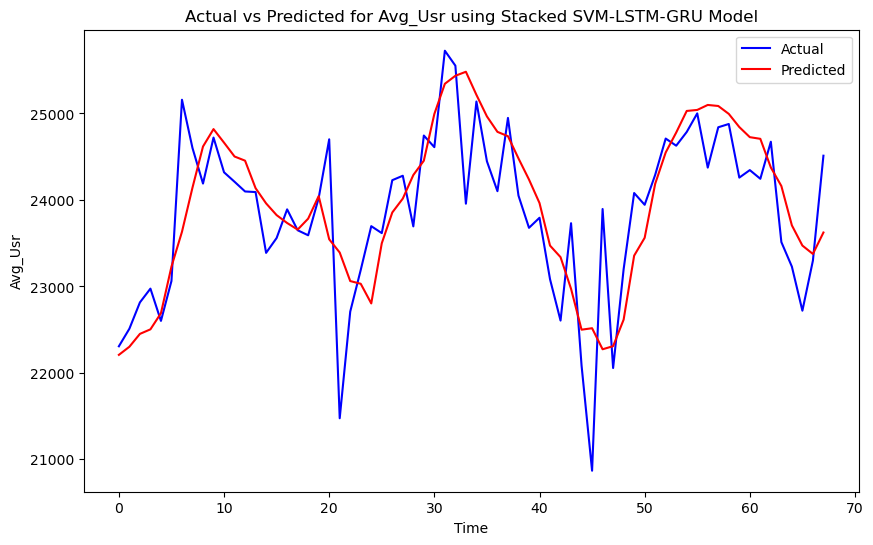

In [16]:

# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Tdata.csv')

# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'Avg_Usr'
feature = 'Avg_Usr'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# SVM Model Prediction
look_back = 3
X_train_svm, y_train_svm = create_dataset_svm(train, look_back=look_back)
X_test_svm, y_test_svm = create_dataset_svm(test, look_back=look_back)

# Hyperparameter search for SVM units
best_mse_svm = float('inf')
best_svm_params = {}

# SVM hyperparameters to tune
svm_kernels = ['linear', 'rbf', 'poly']  # Different kernel functions
svm_C_values = [0.1, 1, 10]  # Regularization parameter (penalty)
svm_gamma_values = ['scale', 'auto']  # Kernel coefficient

for kernel in svm_kernels:
    for C in svm_C_values:
        for gamma in svm_gamma_values:
            print(f"Training SVM with kernel={kernel}, C={C}, gamma={gamma}")
            svm_model = SVR(kernel=kernel, C=C, gamma=gamma)
            svm_model.fit(X_train_svm, y_train_svm)

            # Predict and calculate MSE
            train_predict_svm = svm_model.predict(X_train_svm)
            test_predict_svm = svm_model.predict(X_test_svm)

            mse_svm = mean_squared_error(y_test_svm, test_predict_svm)
            print(f"MSE for SVM: {mse_svm}")

            if mse_svm < best_mse_svm:
                best_mse_svm = mse_svm
                best_svm_params = {'kernel': kernel, 'C': C, 'gamma': gamma}
                best_svm_model = svm_model

print(f'Best SVM params: {best_svm_params}, MSE: {best_mse_svm}')

# Prepare the data for LSTM/GRU hybrid using best SVM predictions
def create_dataset_hybrid(svm_predictions, original_data, look_back=1):
    X, Y = [], []
    for i in range(len(svm_predictions) - look_back):
        feature_set = np.hstack((original_data[i:(i + look_back)], svm_predictions[i:(i + look_back)].reshape(-1, 1)))
        X.append(feature_set)
        Y.append(original_data[i + look_back, 0])
    return np.array(X), np.array(Y)

# Create dataset for LSTM using SVM predictions
X_train_lstm, y_train_lstm = create_dataset_hybrid(train_predict_svm, train, look_back=look_back)
X_test_lstm, y_test_lstm = create_dataset_hybrid(test_predict_svm, test, look_back=look_back)

# Reshape input data for LSTM (samples, timesteps, features)
X_train_lstm = np.reshape(X_train_lstm, (X_train_lstm.shape[0], X_train_lstm.shape[1], 2))
X_test_lstm = np.reshape(X_test_lstm, (X_test_lstm.shape[0], X_test_lstm.shape[1], 2))

# Function to build and train LSTM and GRU models
def build_lstm_gru_model(input_shape, lstm_units, gru_units, dropout_rate):
    model = Sequential()
    model.add(LSTM(lstm_units, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(dropout_rate))
    model.add(GRU(gru_units, return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Experiment with different LSTM, GRU units, and dropout rates
best_mse = float('inf')
best_params = {}
best_model = None

# Loop through different configurations
for lstm_units in [50, 100]:
    for gru_units in [50, 100, 150]:
        for dropout_rate in [0.2, 0.3]:
            for batch_size in [32, 64]:
                for epochs in [50, 100]:
                    print(f"Training LSTM-GRU with LSTM units={lstm_units}, GRU units={gru_units}, dropout_rate={dropout_rate}, batch_size={batch_size}, epochs={epochs}")
                    model = build_lstm_gru_model((look_back, 2), lstm_units, gru_units, dropout_rate)
                    model.fit(X_train_lstm, y_train_lstm, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=1)

                    # Predict
                    test_predict = model.predict(X_test_lstm)
                    
                    # Calculate MSE
                    mse = mean_squared_error(y_test_lstm, test_predict)
                    print(f'MSE: {mse}')

                    if mse < best_mse:
                        best_mse = mse
                        best_params = {'lstm_units': lstm_units, 'gru_units': gru_units, 'dropout_rate': dropout_rate, 'batch_size': batch_size, 'epochs': epochs}
                        best_model = model

print(f'Best MSE: {best_mse} with params: {best_params}')

# Predict with the best model
best_test_predict = best_model.predict(X_test_lstm)

# Invert predictions and actual values back to original scale
best_test_predict = scaler.inverse_transform(best_test_predict)
y_test_lstm = scaler.inverse_transform([y_test_lstm])

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(y_test_lstm[0], label='Actual', color='blue')
plt.plot(best_test_predict, label='Predicted', color='red')
plt.title(f'Actual vs Predicted for Avg_Usr using Stacked SVM-LSTM-GRU Model')
plt.xlabel('Time')
plt.ylabel('Avg_Usr')
plt.legend()
plt.show()

In [6]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [7]:
# Define features and target
selected_features = [
    'Avg_Usr_TP_DL', 'Avg_Usr_TP_UL', 'CSSR', 
    'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE', 
    'DL_QPSK_PROPORTION', 'DL_TRAFFIC_MB', 'Max_Usr', 
    'S1_SIG_SUCC'
]
target_feature = 'Avg_Usr'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + selected_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Function to create dataset matrix for LSTM
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is the first column after scaling
    return np.array(X), np.array(Y)

# Function to train LSTM model
def train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(LSTM(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=10)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history

# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'adam'
look_back = 3

# Dictionary to store MSE and R-squared for each feature or combination
evaluation_scores = []

# Step 1: Train LSTM model with each feature individually
for feature in selected_features:
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)

    # Reshape input data to 3D (samples, timesteps, features) for LSTM input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

    # Train LSTM model
    model, test_predict, history = train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

    # Ensure proper shape for evaluation
    y_test = y_test.flatten()
    test_predict = test_predict.flatten()

    # Calculate MSE and R-squared
    if not np.isnan(y_test).any() and not np.isnan(test_predict).any():
        mse = mean_squared_error(y_test, test_predict)
        r_squared = r2_score(y_test, test_predict)
    else:
        mse = np.nan
        r_squared = np.nan

    evaluation_scores.append({"Features": feature, "MSE": mse, "R-squared": r_squared})

# Step 2: Train LSTM model with all 10 features combined
selected_data = data[[target_feature] + selected_features]
data_scaled = scaler.fit_transform(selected_data)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

X_train, y_train = create_dataset(train_data, look_back=look_back)
X_test, y_test = create_dataset(test_data, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for LSTM input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Train LSTM model
model, test_predict, history = train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Ensure proper shape for evaluation
y_test = y_test.flatten()
test_predict = test_predict.flatten()

# Calculate MSE and R-squared
if not np.isnan(y_test).any() and not np.isnan(test_predict).any():
    mse = mean_squared_error(y_test, test_predict)
    r_squared = r2_score(y_test, test_predict)
else:
    mse = np.nan
    r_squared = np.nan

evaluation_scores.append({"Features": "All 10 Features Combined", "MSE": mse, "R-squared": r_squared})

# Convert results to DataFrame and sort by MSE
evaluation_df = pd.DataFrame(evaluation_scores)
evaluation_df = evaluation_df.sort_values(by="MSE").reset_index(drop=True)

# Display the table
print(evaluation_df)

3/3 [==============================] - 1s 5ms/step
                    Features       MSE  R-squared
0                 DL_LATENCY  0.006145   0.172928
1          DL_PACK_LOSS_RATE  0.006411   0.137066
2                       CSSR  0.006990   0.059205
3                    Max_Usr  0.007086   0.046164
4              DL_TRAFFIC_MB  0.008447  -0.136944
5         DL_QPSK_PROPORTION  0.009507  -0.279665
6              Avg_Usr_TP_UL  0.011766  -0.583766
7   All 10 Features Combined  0.013318  -0.792546
8              Avg_Usr_TP_DL  0.016043  -1.159408
9       DL_256QAM_PROPORTION  0.025168  -2.387603
10               S1_SIG_SUCC  0.039668  -4.339336


In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import ParameterGrid

# Define features and target
selected_features = [
    'Avg_Usr_TP_DL', 'Avg_Usr_TP_UL', 'CSSR', 
    'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE', 
    'DL_QPSK_PROPORTION', 'DL_TRAFFIC_MB', 'Max_Usr', 
    'S1_SIG_SUCC'
]
target_feature = 'Avg_Usr'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + selected_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Function to create dataset matrix for LSTM
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is the first column after scaling
    return np.array(X), np.array(Y)

# Function to train LSTM model
def train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(LSTM(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=10)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history

# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'adam'
look_back = 3

# Dictionary to store MSE and R-squared for each feature or combination
evaluation_scores = []

# Step 1: Train LSTM model with each feature individually
for feature in selected_features:
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)

    # Reshape input data to 3D (samples, timesteps, features) for LSTM input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

    # Train LSTM model
    model, test_predict, history = train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

    # Ensure proper shape for evaluation
    y_test = y_test.flatten()
    test_predict = test_predict.flatten()

    # Calculate MSE and R-squared
    if not np.isnan(y_test).any() and not np.isnan(test_predict).any():
        mse = mean_squared_error(y_test, test_predict)
        r_squared = r2_score(y_test, test_predict)
    else:
        mse = np.nan
        r_squared = np.nan

    evaluation_scores.append({"Features": feature, "MSE": mse, "R-squared": r_squared})

# Sort features based on MSE to determine order of addition
evaluation_df = pd.DataFrame(evaluation_scores).sort_values(by="MSE").reset_index(drop=True)

# Step 2: Incrementally add features based on MSE ranking
final_scores = []
best_features = []

for index, row in evaluation_df.iterrows():
    best_features.append(row["Features"])
    selected_data = data[[target_feature] + best_features]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)

    # Reshape input data to 3D (samples, timesteps, features) for LSTM input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

    # Train LSTM model
    model, test_predict, history = train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

    # Ensure proper shape for evaluation
    y_test = y_test.flatten()
    test_predict = test_predict.flatten()

    # Calculate MSE and R-squared
    if not np.isnan(y_test).any() and not np.isnan(test_predict).any():
        mse = mean_squared_error(y_test, test_predict)
        r_squared = r2_score(y_test, test_predict)
    else:
        mse = np.nan
        r_squared = np.nan

    final_scores.append({"Features": ", ".join(best_features), "MSE": mse, "R-squared": r_squared})

# Convert final results to DataFrame
final_evaluation_df = pd.DataFrame(final_scores)

# Display the final table
print(final_evaluation_df)


3/3 [==============================] - 1s 3ms/step
                                            Features       MSE  R-squared
0                                      DL_TRAFFIC_MB  0.005642   0.240613
1                  DL_TRAFFIC_MB, DL_QPSK_PROPORTION  0.009033  -0.215873
2            DL_TRAFFIC_MB, DL_QPSK_PROPORTION, CSSR  0.009531  -0.282881
3   DL_TRAFFIC_MB, DL_QPSK_PROPORTION, CSSR, Max_Usr  0.015968  -1.149332
4  DL_TRAFFIC_MB, DL_QPSK_PROPORTION, CSSR, Max_U...  0.010260  -0.380976
5  DL_TRAFFIC_MB, DL_QPSK_PROPORTION, CSSR, Max_U...  0.022842  -2.074547
6  DL_TRAFFIC_MB, DL_QPSK_PROPORTION, CSSR, Max_U...  0.026361  -2.548249
7  DL_TRAFFIC_MB, DL_QPSK_PROPORTION, CSSR, Max_U...  0.012082  -0.626219
8  DL_TRAFFIC_MB, DL_QPSK_PROPORTION, CSSR, Max_U...  0.016598  -1.234051
9  DL_TRAFFIC_MB, DL_QPSK_PROPORTION, CSSR, Max_U...  0.066281  -7.921421


In [10]:
final_evaluation_df.to_excel("evaluation_results.xlsx", index=False) 